# SA Implementation v5 — Normalized Profiles, L3, Objective C

Builds directly on `SA_Implementation_v4.ipynb`, same structure and comment style,
extended per the Aug 5 supervisor meeting.

**What's new in v5:**

| | v4 | v5 (this notebook) |
|---|---|---|
| Profile violations | raw counts (days, sessions, gaps), divided by classes taught | **every profile normalized to [0,1] per tutor** via a tutor-specific ceiling, before weighting |
| P3 (compact week) | raw day count | **thresholded**: only the 4th and 5th day used cost anything |
| P4 (prefers full week) | mirror of P3 | **unchanged formula**, no longer P3's mirror since P3 gained a threshold |
| P5 (prefers idle time) | violation only at exactly 0-minute gap | violation for **any gap under one full slot (120 min)** |
| P6 (dislikes idle time) | violation for any gap > 0 | violation only for a **genuine free slot (>= 120 min)** |
| Logical constraints | L1, L2 | **+ L3**: max 6 productive hours/day, literature-grounded (Lagawid 2024, citing RA 4670) |
| `cost_aggregate_only` | hard + logical only | **+ mean(V)**, per supervisor |
| Objectives | A (Jain), B (SD) | **+ Objective C**: normalized composite (0.40 mean + 0.35 sd + 0.25 worst-10% burden), kept separate from B, not a replacement |
| Seeds | sequential 0-9 | **scattered**: 42, 47, 59, 123, 1000, 7, 88, 256, 4096, 31337 |
| Tutor-level detail | ad-hoc, outside the notebook | **built in**: Section 12, per-profile raw/ceiling/normalized breakdown for any tutor |

Everything else (room-type-aware selection, atomic merged-group moves, the campus fix,
H1-H6, L1-L2 logic, multi-slot sessions, Gini/Atkinson)
carries over unchanged from v4.


## 0. Configuration

In [1]:
import csv
import math
import random
import time
import sys
import subprocess
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt

# --Husain Naser update: FINAL FREEZE dependency check. Statistical tests are
# reporting-only, but the final notebook should run top-to-bottom without a separate
# manual installation cell or pip progress dump. Install SciPy quietly only if missing.
try:
    from scipy.stats import wilcoxon, pearsonr
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "scipy", "--quiet"],
        check=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    from scipy.stats import wilcoxon, pearsonr
# ---end of mod: husain naser---

SEMESTER = "25B"
DATA_DIR = "/Users/narjishubail/Library/CloudStorage/OneDrive-BahrainPolytechnic/MSc AI/Thesis/Data/Cleaned Data V4"   # folder containing the Cleaned Data V4 files -- adjust to your local path
#DATA_DIR = "Cleaned Data V4" #Husain naser: I'm just storing it within same directory. Change back to above row to restore original path

SCHEDULE_CSV = f"{DATA_DIR}/schedule_cleaned_it_{SEMESTER}.csv"
TUTOR_PROFILE_CSV = f"{DATA_DIR}/tutors_anonymized_it.csv"
ROOM_CSV = f"{DATA_DIR}/rooms_capacities.csv"
COURSE_CLASH_TEMPLATE = f"{DATA_DIR}/Course_Clash_Avoidance_Template.xlsx"

HARD_PENALTY = 1000     # alpha
LOGICAL_PENALTY = 50    # beta -- L1, L2, L3 all live here
IDLE_CAP_MINUTES = 240  # L1: 4-hour idle cap
MAX_PRODUCTIVE_HOURS = 6  # L3: literature-grounded, see markdown below
SLOT_MINUTES = 120
ATKINSON_EPSILON = 0.5

PROFILE_COLS = [f"P{i}" for i in range(1, 9)]
TOTAL_DAYS_AVAILABLE = 5  # Sunday-Thursday

# ---- simulated annealing hyperparameters ----
# --Husain Naser update: 3000/1000 iterations ended before the model
# consistently repaired feasibility. Changed to 10000
# derive cooling from the requested final temperature so changing the iteration count
# does not distort SA.
MAIN_RUN_ITERATIONS = 10000
ROBUSTNESS_ITERATIONS = 10000 # keep Stage 1 as-is 
STAGE2_ITERATIONS = 20000 # Husain - convergence test only; Stage 1 stays at 10k

T0 = 50.0
FINAL_T = 0.01
MAIN_COOLING = (FINAL_T / T0) ** (1 / MAIN_RUN_ITERATIONS)
ROBUSTNESS_COOLING = (FINAL_T / T0) ** (1 / ROBUSTNESS_ITERATIONS)
COOLING = MAIN_COOLING  # retained for the original Section 8 calls

# The fairness-only refinement works on a much smaller soft-objective scale.
SOFT_T0 = 0.10
SOFT_FINAL_T = 0.0001
RUN_FULL_MULTI_SEED = True # Husain Naser: if False, only 2 seeds will run, for debugging faster

# --Husain Naser update: runtime controls only; these do NOT change the SA objective,
# seeds, temperatures, cooling schedule, proposal probabilities, or acceptance rule.
# FINAL FREEZE: the earlier lambda-sensitivity direction is retired and remains OFF.
RUN_LAMBDA_SENSITIVITY = False  # FINAL : retired after the pre-registered endpoint test
# The fast path is regression-checked against the original calculations on the first
# few proposals of every Stage-2 run and again on the returned best timetable.
FAST_EQUIVALENCE_ASSERTS = True
FAST_EQUIVALENCE_SAMPLES = 25
# ---end of mod: husain naser---

# Genuinely scattered seeds, not sequential 0-9, per supervisor instruction
SEEDS = [42, 47, 59, 123, 1000, 7, 88, 256, 4096, 31337]


## 1. Load data

Same as v4: real durations, `slots_needed = ceil(duration/120)`, room type and campus
looked up per room, weight vectors loaded per tutor across all 8 profiles.

In [2]:
def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

schedule_rows = load_csv(SCHEDULE_CSV)
room_rows = load_csv(ROOM_CSV)
tutor_rows = load_csv(TUTOR_PROFILE_CSV)

room_capacity_by_id = {r["ROOM_ID"]: int(r["CAPACITY"]) for r in room_rows}
room_type_by_id = {r["ROOM_ID"]: r["ROOM_TYPE"] for r in room_rows}
room_building_by_id = {r["ROOM_ID"]: r["BUILDING_ID"] for r in room_rows}

def derive_campus(building_id):
    if building_id == "UOB":
        return "B"
    last = building_id[-1]
    return last if last.isalpha() else "A"

room_campus_by_id = {rid: derive_campus(b) for rid, b in room_building_by_id.items()}
tutor_weights = {r["TUTOR_ID"]: {p: float(r[p]) for p in PROFILE_COLS} for r in tutor_rows}

# --Husain Naser update: fail early if the input files would silently invalidate the
# constraint or preference calculations. These checks do not change any timetable.
missing_rooms = sorted({r["ROOM_ID"] for r in schedule_rows} - set(room_capacity_by_id))
missing_tutors = sorted({r["TUTOR_ID"] for r in schedule_rows} - set(tutor_weights))
assert not missing_rooms, f"Rooms missing from rooms_capacities.csv: {missing_rooms}"
assert not missing_tutors, f"Tutors missing from tutors_anonymized_it.csv: {missing_tutors}"

bad_weights = {
    tutor: weights for tutor, weights in tutor_weights.items()
    if any(w < 0 or w > 1 for w in weights.values())
    or abs(sum(weights.values()) - 1.0) > 1e-4
}
assert not bad_weights, f"Invalid tutor preference weights: {bad_weights}"

for left, right in [("P1", "P2"), ("P3", "P4"), ("P5", "P6")]:
    contradictory = [
        tutor for tutor, weights in tutor_weights.items()
        if weights[left] > 0 and weights[right] > 0
    ]
    assert not contradictory, f"Contradictory profiles {left}/{right}: {contradictory}"
# ---end of mod: husain naser---

def to_minutes(hhmm):
    h, m = map(int, hhmm.split(":"))
    return h * 60 + m

DAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

def slots_needed_for(duration_minutes):
    return math.ceil(duration_minutes / SLOT_MINUTES)

sessions = []
for r in schedule_rows:
    start_min = to_minutes(r["START_TIME"])
    end_min = to_minutes(r["END_TIME"])
    sessions.append({
        "course": r["COURSE_ID"], "class_id": r["CLASS_ID"], "section": r["SECTION"],
        "tutor": r["TUTOR_ID"], "enrolled": int(r["ENROLLED_STUDENTS"]),
        "day": r["DAY"], "start": start_min, "duration": end_min - start_min,
        "slots_needed": slots_needed_for(end_min - start_min),
        "room": r["ROOM_ID"],
        # --Husain Naser update: campus must always follow the selected room metadata.
        "campus": room_campus_by_id.get(r["ROOM_ID"], r["CAMPUS_ID"]),
        # ---end of mod: husain naser---
        "merged_group": r["MERGED_GROUP_ID"] or None,
    })

def session_end(s):
    return s["start"] + s["slots_needed"] * SLOT_MINUTES

# --Husain Naser update: a merged group has multiple administrative rows but represents
# one teaching event for the tutor. Hard constraints still use all original rows.
def teaching_events(sessions_state):
    events = []
    seen_merged = set()
    for s in sessions_state:
        if s["merged_group"]:
            key = (s["tutor"], s["merged_group"])
            if key in seen_merged:
                continue
            seen_merged.add(key)
        events.append(s)
    return events

baseline_merged = defaultdict(list)
for s in sessions:
    if s["merged_group"]:
        baseline_merged[s["merged_group"]].append(s)
for group_id, members in baseline_merged.items():
    event_keys = {
        (m["tutor"], m["day"], m["start"], m["room"], m["duration"])
        for m in members
    }
    assert len(event_keys) == 1, f"Merged group is not one atomic teaching event: {group_id}"
# ---end of mod: husain naser---

slot_starts_by_day = defaultdict(set)
for s in sessions:
    slot_starts_by_day[s["day"]].add(s["start"])

# --Husain Naser update: memoize a static lookup used thousands of times during SA.
# The underlying slot set never changes, and the original list-comprehension order is
# preserved exactly on first computation, so this removes repeated work only.
_VALID_STARTS_CACHE = {}
def valid_starts_for(day, slots_needed):
    key = (day, slots_needed)
    if key not in _VALID_STARTS_CACHE:
        starts = slot_starts_by_day.get(day, set())
        _VALID_STARTS_CACHE[key] = [
            st for st in starts
            if all((st + i * SLOT_MINUTES) in starts for i in range(slots_needed))
        ]
    return _VALID_STARTS_CACHE[key]
# ---end of mod: husain naser---

all_room_ids = sorted(room_capacity_by_id.keys())
rooms_by_type = defaultdict(list)
for rid, rtype in room_type_by_id.items():
    rooms_by_type[rtype].append(rid)

print(f"Semester {SEMESTER}: {len(sessions)} sessions, "
      f"{len(set(s['tutor'] for s in sessions))} tutors, "
      f"{sum(1 for s in sessions if s['merged_group'])} sessions in a merged group.")
# --Husain Naser update: make the merged-row correction visible when the notebook runs.
print(f"Distinct tutor teaching events after merged-group deduplication: {len(teaching_events(sessions))}")
# ---end of mod: husain naser---

pd.DataFrame(sessions).head()


Semester 25B: 556 sessions, 79 tutors, 30 sessions in a merged group.
Distinct tutor teaching events after merged-group deduplication: 541


,course,class_id,section,tutor,enrolled,day,start,duration,slots_needed,room,campus,merged_group
0,IT6001,20873,001,T118,24,Monday,720,110,1,5.04,A,None
1,IT6001,20873,001,T118,24,Wednesday,720,110,1,5.04,A,None
2,IT6001,20878,003,T118,24,Tuesday,600,110,1,5.05,A,None
3,IT6001,20878,003,T118,24,Sunday,600,110,1,5.05,A,None
4,IT6001,20881,004,T118,26,Monday,600,110,1,5.05,A,None


## 2. Hard constraints (H1-H6)

Unchanged from v4.

In [3]:
def h1_assignment_completeness(sessions_state):
    # --Husain Naser update: make H1 an actual audit instead of a hard-coded zero.
    missing_assignment = sum(
        1 for s in sessions_state if not s.get("tutor") or not s.get("room")
    )
    return missing_assignment + abs(len(sessions_state) - len(sessions))
    # ---end of mod: husain naser---


def h2_h3_clashes(sessions_state):
    """Room (H2) and tutor (H3) clashes via interval overlap. Merged-group members
    excluded from clashing with each other."""
    room_groups = defaultdict(list)
    tutor_groups = defaultdict(list)
    for s in sessions_state:
        room_groups[(s["room"], s["day"])].append(s)
        tutor_groups[(s["tutor"], s["day"])].append(s)

    def count_overlaps(groups):
        total = 0
        for key, items in groups.items():
            items = sorted(items, key=lambda s: s["start"])
            for i in range(len(items)):
                for j in range(i + 1, len(items)):
                    if items[j]["start"] >= session_end(items[i]):
                        break
                    gi, gj = items[i]["merged_group"], items[j]["merged_group"]
                    if gi is not None and gi == gj:
                        continue
                    total += 1
        return total
    return count_overlaps(room_groups), count_overlaps(tutor_groups)


def h4_capacity_violations(sessions_state):
    merged_totals = defaultdict(int)
    merged_room = {}
    for s in sessions_state:
        if s["merged_group"]:
            merged_totals[s["merged_group"]] += s["enrolled"]
            merged_room[s["merged_group"]] = s["room"]
    violations, unknown_skipped = 0, 0
    checked_groups = set()
    for s in sessions_state:
        if s["merged_group"]:
            if s["merged_group"] in checked_groups:
                continue
            checked_groups.add(s["merged_group"])
            cap = room_capacity_by_id.get(merged_room[s["merged_group"]])
            if cap is None:
                unknown_skipped += 1; continue
            if cap < merged_totals[s["merged_group"]]:
                violations += 1
        else:
            cap = room_capacity_by_id.get(s["room"])
            if cap is None:
                unknown_skipped += 1; continue
            if cap < s["enrolled"]:
                violations += 1
    return violations, unknown_skipped


def h5_cross_campus(sessions_state):
    tutor_day = defaultdict(list)
    # --Husain Naser update: merged administrative rows count as one tutor event.
    for s in teaching_events(sessions_state):
        tutor_day[(s["tutor"], s["day"])].append(s)
    # ---end of mod: husain naser---
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i+1]["start"] == session_end(items[i]) and items[i]["campus"] != items[i+1]["campus"]:
                total += 1
    return total


def h6a_two_section_courses(sessions_state):
    by_course_section = defaultdict(list)
    for s in sessions_state:
        by_course_section[(s["course"], s["section"])].append(s)
    course_sections = defaultdict(set)
    for course, section in by_course_section:
        course_sections[course].add(section)
    total = 0
    for course, secs in course_sections.items():
        if len(secs) != 2:
            continue
        secs = sorted(secs)
        group_a, group_b = by_course_section[(course, secs[0])], by_course_section[(course, secs[1])]
        for sa in group_a:
            for sb in group_b:
                if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                    total += 1
    return total


def load_course_clash_groups(path, semester):
    try:
        df = pd.read_excel(path, sheet_name="Course_Clash_Groups")
    except FileNotFoundError:
        print(f"WARNING: {path} not found -- H6b will contribute 0.")
        return []
    groups = []
    for _, row in df.iterrows():
        if str(row.get("COHORT_LABEL", "")).strip().upper().startswith("EXAMPLE"):
            continue
        if str(row.get("SEMESTER", "")).strip() != semester:
            continue
        courses = [str(row[c]).strip() for c in ["COURSE_1", "COURSE_2", "COURSE_3", "COURSE_4"]
                   if str(row.get(c, "")).strip() and str(row[c]).strip().lower() != "nan"]
        if len(courses) >= 2:
            groups.append(courses)
    return groups

def h6b_manual_course_groups(sessions_state, course_groups):
    by_course = defaultdict(list)
    for s in sessions_state:
        by_course[s["course"]].append(s)
    total = 0
    for group in course_groups:
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                for sa in by_course.get(group[i], []):
                    for sb in by_course.get(group[j], []):
                        if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                            total += 1
    return total

course_clash_groups = load_course_clash_groups(COURSE_CLASH_TEMPLATE, SEMESTER)
print(f"Manual course-clash groups loaded for {SEMESTER}: {len(course_clash_groups)}")


def count_hard_violations_breakdown(sessions_state):
    room_c, tutor_c = h2_h3_clashes(sessions_state)
    cap_v, cap_unknown = h4_capacity_violations(sessions_state)
    return {
        "H1_assignment_completeness": h1_assignment_completeness(sessions_state),
        "H2_room_clash": room_c, "H3_tutor_clash": tutor_c,
        "H4_capacity": cap_v, "H4_capacity_unknown_skipped": cap_unknown,
        "H5_cross_campus": h5_cross_campus(sessions_state),
        "H6a_two_section_overlap": h6a_two_section_courses(sessions_state),
        "H6b_manual_group_overlap": h6b_manual_course_groups(sessions_state, course_clash_groups),
    }

def count_hard_violations(sessions_state):
    b = count_hard_violations_breakdown(sessions_state)
    return sum(v for k, v in b.items() if k != "H4_capacity_unknown_skipped")


Manual course-clash groups loaded for 25B: 2


## 3. Logical constraints (L1, L2, L3)

L1 and L2 unchanged. **L3 is new**: no more than 6 productive teaching hours in a single
day; each additional whole hour beyond 6 is one violation. Grounded in Lagawid (2024),
*Overloading in Elementary School Teachers: A Review*, which cites the Philippines'
Magna Carta for Public School Teachers (Republic Act No. 4670) capping actual classroom
instruction at 6 hours/day, plus supporting physiological literature on teacher fatigue
over a teaching day (see `Demo_Prep_Notes.md` / thesis literature list for the full
citation set).

In [4]:
def l1_idle_cap_violations(sessions_state):
    tutor_day = defaultdict(list)
    # --Husain Naser update: merged administrative rows count as one tutor event.
    for s in teaching_events(sessions_state):
        tutor_day[(s["tutor"], s["day"])].append(s)
    # ---end of mod: husain naser---
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i+1]["start"] - session_end(items[i]) > IDLE_CAP_MINUTES:
                total += 1
    return total


def l2_same_class_same_day(sessions_state):
    groups = defaultdict(list)
    for s in sessions_state:
        groups[s["class_id"]].append(s["day"])
    total = 0
    for class_id, days in groups.items():
        day_counts = Counter(days)
        total += sum(c - 1 for c in day_counts.values() if c > 1)
    return total


def l3_max_hours_violations(sessions_state):
    """Sums each session's REAL duration (not the slot-block reservation) per tutor per
    day; each whole hour beyond MAX_PRODUCTIVE_HOURS is one violation. Uses real
    duration deliberately -- L3 is about actual teaching time, not the scheduling grid."""
    tutor_day_minutes = defaultdict(int)
    # --Husain Naser update: a merged group is one real teaching event, not two hours entries.
    for s in teaching_events(sessions_state):
        tutor_day_minutes[(s["tutor"], s["day"])] += s["duration"]
    # ---end of mod: husain naser---
    total = 0
    for key, minutes in tutor_day_minutes.items():
        hours_over = minutes / 60 - MAX_PRODUCTIVE_HOURS
        if hours_over >= 1:
            total += math.floor(hours_over)
    return total


def count_logical_violations_breakdown(sessions_state):
    return {"L1_idle_gap_over_4h": l1_idle_cap_violations(sessions_state),
            "L2_same_class_same_day": l2_same_class_same_day(sessions_state),
            "L3_over_6_productive_hours": l3_max_hours_violations(sessions_state)}

def count_logical_violations(sessions_state):
    return sum(count_logical_violations_breakdown(sessions_state).values())


# --Husain Naser update: search-only feasibility predicate with exact semantics.
# The original counters above remain unchanged for reporting. During Stage 2 we only need
# the boolean question "is this candidate still 0/0?". Each H/L function returns a
# non-negative violation count, so stopping at the first non-zero count is logically
# identical to computing every count and summing them. This changes runtime, not feasibility.
def is_fully_feasible_fast(sessions_state):
    if h1_assignment_completeness(sessions_state) != 0:
        return False

    room_c, tutor_c = h2_h3_clashes(sessions_state)
    if room_c != 0 or tutor_c != 0:
        return False

    cap_v, _ = h4_capacity_violations(sessions_state)
    if cap_v != 0:
        return False

    if h5_cross_campus(sessions_state) != 0:
        return False
    if h6a_two_section_courses(sessions_state) != 0:
        return False
    if course_clash_groups and h6b_manual_course_groups(sessions_state, course_clash_groups) != 0:
        return False

    if l1_idle_cap_violations(sessions_state) != 0:
        return False
    if l2_same_class_same_day(sessions_state) != 0:
        return False
    if l3_max_hours_violations(sessions_state) != 0:
        return False

    return True
# ---end of mod: husain naser---


## 4. Soft constraints — normalized [0,1] per tutor

The biggest change in v5. Every profile's raw violation count is divided by a
**tutor-specific ceiling** (that tutor's own maximum possible violation, not a fixed
institutional number) before being weighted, so `V(t) = Σ weight_p × (raw_p / ceiling_p)`
is bounded in `[0,1]` by construction, a convex combination of numbers in `[0,1]` can't
exceed 1. This replaces v4's "divide the weighted sum by classes taught" approach
entirely, not just adjusts it.

**How each violation count actually increases, and what it's normalized against:**

| Profile | What increases the count | Ceiling (tutor-specific "worst case") |
|---|---|---|
| P1 morning-only | every session at/after 12:00 | N (this tutor's total sessions) |
| P2 night owl | every session before 12:00 | N |
| P3 compact week | every day beyond the 1st-3rd used (4th, 5th day each cost 1) | `max(0, min(N,5) − 3)` |
| P4 prefers full week | every day out of 5 NOT taught on, no threshold | `5 − min_days(t)` |
| P5 prefers idle time | every same-day consecutive gap **under** 120 min (incl. 0) | `N − min_days(t)` |
| P6 dislikes idle time | every same-day consecutive gap of **120 min or more** | `N − min_days(t)` |
| P7 campus-consistency | every campus beyond the first, on any day with >1 campus | `N − min_days(t)` (approximation) |
| P8 no preference | never | ceiling is moot, always 0 |

`min_days(t)` = the largest weekly-meeting count of any single class this tutor
teaches (L2 already forces that class's own sessions onto different days, so this is a
real, non-negotiable floor on how few days this tutor could possibly use).

Note P3 and P4 are **no longer mirror images**: P3 forgives the first 3 days, P4
forgives nothing.

In [5]:
def is_morning(start_minute):
    return start_minute < 12 * 60

def compute_min_days(sessions_state):
    """Largest weekly-meeting count of any single class, per tutor. Tutor-to-class
    assignment is fixed input and never changes during SA, so this (and total session
    count N per tutor) is computed ONCE below, not recomputed on every cost evaluation,
    that recomputation was the single biggest performance cost in early testing."""
    tutor_class_meetings = defaultdict(lambda: defaultdict(int))
    for s in sessions_state:
        tutor_class_meetings[s["tutor"]][s["class_id"]] += 1
    return {t: max(counts.values()) for t, counts in tutor_class_meetings.items() if counts}

# --Husain Naser bug fix: compute both minimum-day and event-count ceilings from
# the same merged-group-deduplicated teaching-event view. Previously MIN_DAYS_MAP
# used all administrative rows while TUTOR_N_MAP used teaching events.
MIN_DAYS_MAP = compute_min_days(teaching_events(sessions))
TUTOR_N_MAP = defaultdict(int)
for s in teaching_events(sessions):
    TUTOR_N_MAP[s["tutor"]] += 1
# ---end of mod: husain naser---


def raw_and_ceiling(profile, day_groups, campus_by_day, N, min_days_t):
    """Returns (raw, ceiling) for one profile, per the table above."""
    if profile == "P1":
        raw = sum(1 for day, items in day_groups.items() for s in items if not is_morning(s["start"]))
        return raw, N
    if profile == "P2":
        raw = sum(1 for day, items in day_groups.items() for s in items if is_morning(s["start"]))
        return raw, N
    if profile == "P3":  # compact week, forgives the first 3 days
        days_used = len(day_groups)
        raw = max(0, days_used - 3)
        ceiling = max(0, min(N, TOTAL_DAYS_AVAILABLE) - 3)
        return raw, ceiling
    if profile == "P4":  # prefers full week, forgives nothing
        days_used = len(day_groups)
        raw = max(TOTAL_DAYS_AVAILABLE - days_used, 0)
        ceiling = TOTAL_DAYS_AVAILABLE - min_days_t
        return raw, ceiling
    if profile == "P5":  # prefers idle time -- violation if gap < 1 full slot
        raw = 0
        for day, items in day_groups.items():
            its = sorted(items, key=lambda s: s["start"])
            for i in range(len(its) - 1):
                if its[i+1]["start"] - session_end(its[i]) < SLOT_MINUTES:
                    raw += 1
        ceiling = max(N - min_days_t, 0)
        return raw, ceiling
    if profile == "P6":  # dislikes idle time -- violation if gap >= 1 full slot
        raw = 0
        for day, items in day_groups.items():
            its = sorted(items, key=lambda s: s["start"])
            for i in range(len(its) - 1):
                if its[i+1]["start"] - session_end(its[i]) >= SLOT_MINUTES:
                    raw += 1
        ceiling = max(N - min_days_t, 0)
        return raw, ceiling
    if profile == "P7":  # campus-consistency
        raw = 0
        for day, campuses in campus_by_day.items():
            distinct = len(set(campuses))
            if distinct > 1:
                raw += distinct - 1
        ceiling = max(N - min_days_t, 0)  # approximation, flagged in the change list
        return raw, ceiling
    return 0.0, 0.0  # P8, always 0


def per_tutor_violations(sessions_state):
    """Returns (V, V_detail). V(t) is bounded [0,1]. V_detail keeps the per-profile
    raw/ceiling/normalized/weight breakdown for the tutor-checker in Section 12.
    Uses the precomputed MIN_DAYS_MAP / TUTOR_N_MAP (module-level, computed once above)
    since tutor-to-class assignment never changes during SA."""
    tutor_days = defaultdict(lambda: defaultdict(list))
    tutor_campus_days = defaultdict(lambda: defaultdict(list))
    # --Husain Naser update: merged administrative rows count as one preference event.
    for s in teaching_events(sessions_state):
        tutor_days[s["tutor"]][s["day"]].append(s)
        tutor_campus_days[s["tutor"]][s["day"]].append(s["campus"])
    # ---end of mod: husain naser---

    V, V_detail = {}, {}
    for t, day_groups in tutor_days.items():
        weights = tutor_weights.get(t, {p: (1.0 if p == "P8" else 0.0) for p in PROFILE_COLS})
        N = TUTOR_N_MAP.get(t, 0)
        md_t = MIN_DAYS_MAP.get(t, 1)
        total = 0.0
        detail = {}
        for p in PROFILE_COLS:
            w = weights.get(p, 0.0)
            raw, ceiling = raw_and_ceiling(p, day_groups, tutor_campus_days[t], N, md_t)
            normalized = min((raw / ceiling) if ceiling > 0 else 0.0, 1.0)
            detail[p] = {"raw": raw, "ceiling": ceiling, "normalized": normalized, "weight": w}
            total += w * normalized
        V[t] = total
        V_detail[t] = detail
    return V, V_detail


## 5. Fairness — independent reporting views

The existing Jain, Atkinson, mean/SD/max and burden-Gini views are retained. A satisfaction-Gini view (`1-Gini(1-V)`) is restored from the earlier PUBLISHABLE version as a reporting-only validity check after burden-Gini was found to degenerate when many tutors approach zero burden. No Gini measure gates or drives the search.

<!-- Husain Naser update: metric-validity correction only; no objective was changed. -->

In [6]:
def jain_fairness(V_dict):
    # --Husain Naser update: use fixed satisfaction (1 - burden), not a dynamic
    # max-shift that can improve when the worst tutor is made worse.
    # Literature context: Mühlenthaler & Wanka (Annals of Operations Research, 2016,
    # DOI 10.1007/s10479-014-1553-2) also convert soft-constraint penalties into a
    # beneficial allocation before applying Jain; here V is already normalized to [0,1],
    # so fixed satisfaction = 1 - V gives the same burden-to-benefit interpretation.
    vals = [max(0.0, 1.0 - v) for v in V_dict.values()]
    T = len(vals)
    if T == 0: return 1.0
    s1, s2 = sum(vals), sum(v * v for v in vals)
    if s2 == 0: return 1.0
    return (s1 ** 2) / (T * s2)
    # ---end of mod: husain naser---


def _gini_coefficient(values):
    """Gini coefficient for non-negative values; 0 means equal."""
    vals = sorted(max(0.0, float(v)) for v in values)
    n = len(vals)
    total = sum(vals)
    if n == 0 or total == 0:
        return 0.0
    return sum(
        (2 * (i + 1) - n - 1) * value
        for i, value in enumerate(vals)
    ) / (n * total)


def gini_fairness(V_dict):
    # --Husain Naser update: burden Gini is retained only for continuity and the
    # degeneracy audit. Higher 1-G means more equal BURDEN, but this view can become
    # misleading when many tutors approach exactly zero burden. It is not a headline
    # fairness result in the final study.
    return 1.0 - _gini_coefficient(V_dict.values())
    # ---end of mod: husain naser---


def gini_satisfaction_fairness(V_dict):
    # --Husain Naser update: ported from the earlier PUBLISHABLE notebook after the
    # burden-Gini degeneracy was identified. This is a reporting-only validity check
    # on the beneficial quantity satisfaction = 1 - burden; it is never optimized.
    satisfactions = [max(0.0, 1.0 - v) for v in V_dict.values()]
    return 1.0 - _gini_coefficient(satisfactions)
    # ---end of mod: husain naser---

def atkinson_fairness(V_dict, epsilon):
    # --Husain Naser bug fix: Atkinson is defined over a beneficial quantity.
    # Apply it to tutor satisfaction (1 - burden) without the previous +1 shift,
    # which compressed almost every result into the uninformative 0.99 range.
    vals = [max(0.0, 1.0 - v) for v in V_dict.values()]
    n = len(vals)
    if n == 0:
        return 1.0
    mu = sum(vals) / n
    if mu <= 1e-12:
        return 1.0  # equal zero satisfaction: equality is perfect, level is reported elsewhere
    if epsilon == 1:
        ede = 0.0 if any(v <= 0.0 for v in vals) else math.exp(
            sum(math.log(v) for v in vals) / n
        )
    else:
        ede = (
            sum(v ** (1 - epsilon) for v in vals) / n
        ) ** (1.0 / (1 - epsilon))
    return min(max(ede / mu, 0.0), 1.0)
    # ---end of mod: husain naser---


def mathematical_fairness(V_dict):
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0:
        return {
            "mean": 0.0, "sd": 0.0, "max": 0.0, "top10": 0.0,
            "gini_fairness": 1.0, "gini_coefficient": 0.0,
            "gini_satisfaction_fairness": 1.0,
            "gini_satisfaction_coefficient": 0.0,
            "zero_burden_count": 0,
        }
    mean = sum(vals) / n
    variance = sum((v - mean) ** 2 for v in vals) / n
    # --Husain Naser update: keep the agreed worst-10% burden measure unchanged.
    k = max(1, math.ceil(0.10 * n))
    top10 = sum(sorted(vals, reverse=True)[:k]) / k
    burden_gini = _gini_coefficient(vals)
    satisfaction_gini = _gini_coefficient(max(0.0, 1.0 - v) for v in vals)
    zero_count = sum(abs(v) <= 1e-12 for v in vals)
    # ---end of mod: husain naser---
    return {
        "mean": mean, "sd": math.sqrt(variance), "max": max(vals),
        "top10": top10,
        "gini_fairness": 1.0 - burden_gini,
        "gini_coefficient": burden_gini,
        "gini_satisfaction_fairness": 1.0 - satisfaction_gini,
        "gini_satisfaction_coefficient": satisfaction_gini,
        "zero_burden_count": zero_count,
    }


# --Husain Naser update: one common metric view is used for every timetable comparison.
def burden_metrics(sessions_state):
    V, V_detail = per_tutor_violations(sessions_state)
    return mathematical_fairness(V), V, V_detail


# --Husain Naser update: exact-equivalent search-only burden calculation.
# Stage-2 objectives use V plus mean/SD/top-10%/max (or Jain computed directly from V).
# They do NOT use V_detail or Gini inside the acceptance decision, so constructing those
# objects for every feasible proposal is wasted work. Full metrics are still recomputed
# for the returned best timetable and all reporting remains unchanged.
def per_tutor_violations_search(sessions_state):
    tutor_days = defaultdict(lambda: defaultdict(list))
    tutor_campus_days = defaultdict(lambda: defaultdict(list))

    # Deliberately use the SAME teaching-event order and the SAME raw_and_ceiling()
    # calculations as per_tutor_violations(), so V(t) is numerically identical.
    for s in teaching_events(sessions_state):
        tutor_days[s["tutor"]][s["day"]].append(s)
        tutor_campus_days[s["tutor"]][s["day"]].append(s["campus"])

    V = {}
    for t, day_groups in tutor_days.items():
        weights = tutor_weights.get(
            t, {p: (1.0 if p == "P8" else 0.0) for p in PROFILE_COLS}
        )
        N = TUTOR_N_MAP.get(t, 0)
        md_t = MIN_DAYS_MAP.get(t, 1)
        total = 0.0

        for p in PROFILE_COLS:
            w = weights.get(p, 0.0)
            raw, ceiling = raw_and_ceiling(
                p, day_groups, tutor_campus_days[t], N, md_t
            )
            normalized = min(
                (raw / ceiling) if ceiling > 0 else 0.0,
                1.0,
            )
            total += w * normalized

        V[t] = total

    return V


def mathematical_fairness_search(V_dict):
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0:
        return {"mean": 0.0, "sd": 0.0, "max": 0.0, "top10": 0.0}

    mean = sum(vals) / n
    variance = sum((v - mean) ** 2 for v in vals) / n
    k = max(1, math.ceil(0.10 * n))
    top10 = sum(sorted(vals, reverse=True)[:k]) / k

    return {
        "mean": mean,
        "sd": math.sqrt(variance),
        "max": max(vals),
        "top10": top10,
    }


def burden_metrics_search(sessions_state):
    V = per_tutor_violations_search(sessions_state)
    return mathematical_fairness_search(V), V


def assert_search_metrics_equivalent(
    sessions_state,
    fast_metrics=None,
    fast_V=None,
    label="state",
):
    """Regression guard: verify the fast path against the original full calculation."""
    if fast_metrics is None or fast_V is None:
        fast_metrics, fast_V = burden_metrics_search(sessions_state)

    full_metrics, full_V, _ = burden_metrics(sessions_state)

    if set(fast_V) != set(full_V):
        raise AssertionError(f"{label}: tutor sets differ between fast/full burden paths")

    for tutor in full_V:
        if not math.isclose(fast_V[tutor], full_V[tutor], rel_tol=0.0, abs_tol=1e-12):
            raise AssertionError(
                f"{label}: V mismatch for {tutor}: fast={fast_V[tutor]} full={full_V[tutor]}"
            )

    for key in ("mean", "sd", "top10", "max"):
        if not math.isclose(
            fast_metrics[key], full_metrics[key], rel_tol=0.0, abs_tol=1e-12
        ):
            raise AssertionError(
                f"{label}: metric {key} mismatch: "
                f"fast={fast_metrics[key]} full={full_metrics[key]}"
            )

    return full_metrics, full_V
# ---end of mod: husain naser---

def tutor_change_summary(reference_V, candidate_V):
    changes = {
        tutor: candidate_V.get(tutor, 0.0) - reference_V.get(tutor, 0.0)
        for tutor in set(reference_V) | set(candidate_V)
    }
    worsened = [v for v in changes.values() if v > 1e-9]
    return {
        "tutors_improved": sum(v < -1e-9 for v in changes.values()),
        "tutors_unchanged": sum(abs(v) <= 1e-9 for v in changes.values()),
        "tutors_worsened": len(worsened),
        "mean_deterioration_if_worsened": sum(worsened) / len(worsened) if worsened else 0.0,
        "max_individual_deterioration": max(changes.values(), default=0.0),
    }
# ---end of mod: husain naser---


## 6. Three objective functions

Objectives A and B are unchanged from v4 (Jain-primary, SD-primary). **`cost_aggregate_only`
adds `mean(V)`** and is used only for the Stage-2 Aggregate control after a common feasible
start has been created.

**Objective C is new** (`cost_objective_C_normalized_composite`), a separate function
that does not touch Objective B:

`0.40×normalized_mean + 0.35×normalized_sd + 0.25×normalized_worst10`

Each component is divided by its own baseline value, computed once from the original
unoptimised timetable. Maximum burden remains reported as a diagnostic, but it is not an
active Objective C component.


In [7]:
def _normalize(total, n_sessions):
    N = max(n_sessions, 1)
    ceiling = HARD_PENALTY * N + LOGICAL_PENALTY * N + 1
    return total / ceiling


def cost_jain_primary(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V, V_detail = per_tutor_violations(sessions_state)
    J = jain_fairness(V)
    F_active = 1 - J
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + F_active
    return {
        "total": total, "normalized_total": _normalize(total, len(sessions_state)),
        "hard": hard, "logical": logical, "V": V, "V_detail": V_detail,
        "F_active": F_active, "jain": J, "gini": gini_fairness(V),
        "gini_satisfaction": gini_satisfaction_fairness(V),
        "atkinson": atkinson_fairness(V, ATKINSON_EPSILON), "math": mathematical_fairness(V),
    }


def cost_math_primary(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V, V_detail = per_tutor_violations(sessions_state)
    math_view = mathematical_fairness(V)
    # --Husain Naser update: baseline-normalize B for a common readable scale.
    # This does not change which timetable B prefers.
    F_active = math_view["sd"] / BASE_SD
    # ---end of mod: husain naser---
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + F_active
    return {
        "total": total, "normalized_total": _normalize(total, len(sessions_state)),
        "hard": hard, "logical": logical, "V": V, "V_detail": V_detail,
        "F_active": F_active, "jain": jain_fairness(V), "gini": gini_fairness(V),
        "gini_satisfaction": gini_satisfaction_fairness(V),
        "atkinson": atkinson_fairness(V, ATKINSON_EPSILON), "math": math_view,
    }


# --Husain Naser update: Stage 1 now has one job only: reach 0 hard / 0 logical.
# Tutor burden is deliberately excluded so neither Stage-2 objective influences
# the shared starting timetable.
def cost_feasibility_only(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical
    return {"total": total, "hard": hard, "logical": logical}
# ---end of mod: husain naser---


def cost_aggregate_only(sessions_state):
    """No fairness-function term, but per supervisor, DOES include mean(V) now."""
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V, _ = per_tutor_violations(sessions_state)
    mean_v = sum(V.values()) / max(len(V), 1)
    # --Husain Naser update: baseline-normalize Aggregate for the same readable scale.
    mean_v_normalized = mean_v / BASE_MEAN
    # ---end of mod: husain naser---
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + mean_v_normalized
    return {"total": total, "normalized_total": _normalize(total, len(sessions_state)),
            "hard": hard, "logical": logical, "mean_v": mean_v,
            "F_active": mean_v_normalized, "V": V}


# ---- baseline values for Objective C's normalization, computed once, before any SA run ----
_BASE_V, _ = per_tutor_violations(sessions)
_BASE_MATH = mathematical_fairness(_BASE_V)
BASE_MEAN = max(_BASE_MATH["mean"], 1e-9)
BASE_SD = max(_BASE_MATH["sd"], 1e-9)
BASE_MAX = max(_BASE_MATH["max"], 1e-9)
# --Husain Naser update: normalize the worst-10% mean for Objective C
# Maximum burden remains reported separately, but is no longer an active C component
# because it was frequently just stuck at 1 and gave little guidance.
BASE_TOP10 = max(_BASE_MATH["top10"], 1e-9)
# ---end of mod: husain naser---


def cost_objective_C_normalized_composite(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V, V_detail = per_tutor_violations(sessions_state)
    math_view = mathematical_fairness(V)

    normalized_mean = math_view["mean"] / BASE_MEAN
    normalized_sd = math_view["sd"] / BASE_SD
    # --Husain Naser update: replace the frequently saturated max term with the
    # normalized worst-10% mean, as agreed. Maximum burden is still reported and
    # reported as a diagnostic during feasible fairness refinement.
    normalized_top10 = math_view["top10"] / BASE_TOP10
    F_active = (
        0.40 * normalized_mean
        + 0.35 * normalized_sd
        + 0.25 * normalized_top10
    )
    # ---end of mod: husain naser---

    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + F_active
    return {
        "total": total, "normalized_total": _normalize(total, len(sessions_state)),
        "hard": hard, "logical": logical, "V": V, "V_detail": V_detail,
        "F_active": F_active, "jain": jain_fairness(V), "gini": gini_fairness(V),
        "gini_satisfaction": gini_satisfaction_fairness(V),
        "atkinson": atkinson_fairness(V, ATKINSON_EPSILON), "math": math_view,
        "normalized_mean": normalized_mean, "normalized_sd": normalized_sd,
        "normalized_top10": normalized_top10,
    }


# --Husain Naser update: sensitivity analysis around Objective C; this does NOT
# replace or rewrite Objective C. We re-express the existing 0.40/0.35/0.25 weights as:
#   lambda * mean + (1-lambda) * equity,
# where equity keeps the original SD:worst-10% ratio exactly (0.35:0.25 = 7:5).
# Therefore lambda=0.40 reproduces the existing Objective C EXACTLY, while lambda=1.00
# is the existing mean-only Aggregate control. This turns one arbitrary-looking weight
# choice into a transparent efficiency-equity sensitivity analysis.
#
# Literature context:
# - Mühlenthaler & Wanka (Annals of Operations Research, 2016,
#   DOI 10.1007/s10479-014-1553-2) explicitly study the trade-off between fairness
#   and total soft-constraint violations ("price of fairness").
# - Burget & Rudová, "Teacher-oriented Fairness in Course Timetabling", PATAT 2016,
#   pp. 33-44, explicitly vary the fairness weight and report the resulting trade-off;
#   they note that the preferred weight depends on institutional policy.
def objective_C_lambda_score(metrics, lam):
    if not 0.0 <= lam <= 1.0:
        raise ValueError("lambda must be in [0, 1]")

    normalized_mean = metrics["mean"] / BASE_MEAN
    normalized_sd = metrics["sd"] / BASE_SD
    normalized_top10 = metrics["top10"] / BASE_TOP10

    equity_component = (
        (7.0 / 12.0) * normalized_sd
        + (5.0 / 12.0) * normalized_top10
    )
    return lam * normalized_mean + (1.0 - lam) * equity_component
# ---end of mod: husain naser---


# --Husain Naser update: keep the original Objective C as the primary fairness objective.
# The explicit 0.40 mean + 0.35 SD + 0.25 worst-10% equation above is easier to
# explain and remains the pre-specified main formulation. Lambda is used only in the
# optional sensitivity analysis below to study the efficiency-equity trade-off.
# ---end of mod: husain naser---


# --Husain Naser update: use only the existing objectives during feasible
# refinement. Gini/Jain/Atkinson remain independent reported validation metrics.
def objective_soft_score(cost_fn, metrics, V):
    if cost_fn is cost_jain_primary:
        return 1 - jain_fairness(V)
    if cost_fn is cost_math_primary:
        return metrics["sd"] / BASE_SD
    if cost_fn is cost_objective_C_normalized_composite:
        return (
            0.40 * metrics["mean"] / BASE_MEAN
            + 0.35 * metrics["sd"] / BASE_SD
            + 0.25 * metrics["top10"] / BASE_TOP10
        )
    return metrics["mean"] / BASE_MEAN
# ---end of mod: husain naser---


## 7. Simulated annealing — unchanged from v4

Room-type aware, merged groups move atomically, campus recomputed on every room move.

In [8]:
def sa_optimise(initial_sessions, cost_fn, max_iterations, T0, cooling, rng):
    current = [dict(s) for s in initial_sessions]
    current_cost = cost_fn(current)["total"]
    best = [dict(s) for s in current]
    best_cost = current_cost
    T = T0
    accepted = 0
    history = []

    merged_idx = defaultdict(list)
    for i, s in enumerate(current):
        if s["merged_group"]:
            merged_idx[s["merged_group"]].append(i)

    for it in range(max_iterations):
        idx = rng.randrange(len(current))
        s = current[idx]
        group_indices = merged_idx[s["merged_group"]] if s["merged_group"] else [idx]

        k = max(current[i]["slots_needed"] for i in group_indices)
        candidate_days = [d for d in slot_starts_by_day if valid_starts_for(d, k)]
        if not candidate_days:
            history.append(current_cost); T *= cooling; continue

        current_type = room_type_by_id.get(current[idx]["room"])
        same_type_rooms = rooms_by_type.get(current_type, all_room_ids)

        # --Husain Naser update: preserve room type AND sufficient capacity.
        # Capacity check was missing in the original SA code
        # which could lead to infeasible room assignments and thus hard violations 
        required_capacity = (
            sum(current[i]["enrolled"] for i in group_indices)
            if s["merged_group"] else current[idx]["enrolled"]
        )
        eligible_rooms = [
            room for room in same_type_rooms
            if room_capacity_by_id.get(room, -1) >= required_capacity
        ]
        if not eligible_rooms:
            history.append(current_cost); T *= cooling; continue
        # ---end of mod: husain naser---

        old_state = [(i, current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"])
                     for i in group_indices]

        new_day = rng.choice(candidate_days)
        new_start = rng.choice(valid_starts_for(new_day, k))
        # --Husain Naser update: choose only from the capacity-safe same-type rooms.
        new_room = rng.choice(eligible_rooms)
        # ---end of mod: husain naser---
        new_campus = room_campus_by_id.get(new_room)

        for i in group_indices:
            current[i]["day"] = new_day
            current[i]["start"] = new_start
            current[i]["room"] = new_room
            current[i]["campus"] = new_campus

        new_cost = cost_fn(current)["total"]
        delta = new_cost - current_cost

        if delta <= 0 or rng.random() < math.exp(-delta / max(T, 1e-9)):
            current_cost = new_cost
            accepted += 1
            if current_cost < best_cost:
                best_cost = current_cost
                best = [dict(x) for x in current]
        else:
            for i, day, start, room, campus in old_state:
                current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"] = day, start, room, campus

        history.append(current_cost)
        T *= cooling

    return best, best_cost, accepted, history


def merged_groups_intact(sessions_state):
    groups = defaultdict(list)
    for s in sessions_state:
        if s["merged_group"]:
            groups[s["merged_group"]].append(s)
    broken = 0
    for gid, members in groups.items():
        keys = set((m["day"], m["start"], m["room"]) for m in members)
        if len(keys) > 1:
            broken += 1
    return broken, len(groups)


# --Husain Naser update: refine a soft objective only inside the fully feasible
# region. Human-impact guards were removed to keep this experiment close to the
# original v5 formulation; only 0 hard / 0 logical feasibility is enforced.
def sa_refine_feasible(
    initial_sessions,
    score_fn,
    max_iterations,
    rng,
):
    current = [dict(s) for s in initial_sessions]
    if count_hard_violations(current) != 0 or count_logical_violations(current) != 0:
        raise ValueError("Soft refinement requires a 0 hard / 0 logical starting timetable.")

    current_metrics, current_V = burden_metrics_search(current)
    if FAST_EQUIVALENCE_ASSERTS:
        assert_search_metrics_equivalent(
            current, current_metrics, current_V, label="Stage-2 initial state"
        )
    current_score = score_fn(current_metrics, current_V)
    best = [dict(s) for s in current]
    best_score = current_score
    best_metrics = dict(current_metrics)
    best_V = dict(current_V)

    merged_idx = defaultdict(list)
    for i, s in enumerate(current):
        if s["merged_group"]:
            merged_idx[s["merged_group"]].append(i)

    # --Husain Naser update: room eligibility depends only on static room type/capacity
    # and the moved event's required capacity. Cache the exact original list order.
    eligible_room_cache = {}
    feasibility_asserts_done = 0
    burden_asserts_done = 0
    # ---end of mod: husain naser---

    accepted = 0
    rejected_infeasible = 0
    history = []
    T = SOFT_T0
    cooling = (SOFT_FINAL_T / SOFT_T0) ** (1 / max(max_iterations, 1))

    # --Husain Naser update: retain about 100 best-so-far checkpoints for the
    # convergence chart without storing a full timetable at every iteration.
    trace_every = max(1, max_iterations // 100)
    trace = [{
        "iteration": 0,
        "search_score": best_score,
        "mean": best_metrics["mean"],
        "sd": best_metrics["sd"],
        "top10": best_metrics["top10"],
        "max": best_metrics["max"],
    }]

    def record_trace(iteration):
        if iteration % trace_every == 0 or iteration == max_iterations:
            trace.append({
                "iteration": iteration,
                "search_score": best_score,
                "mean": best_metrics["mean"],
                "sd": best_metrics["sd"],
                "top10": best_metrics["top10"],
                "max": best_metrics["max"],
            })
    # ---end of mod: husain naser---

    for iteration in range(1, max_iterations + 1):
        idx = rng.randrange(len(current))
        selected = current[idx]
        group_indices = (
            merged_idx[selected["merged_group"]]
            if selected["merged_group"] else [idx]
        )

        k = max(current[i]["slots_needed"] for i in group_indices)
        candidate_days = [d for d in slot_starts_by_day if valid_starts_for(d, k)]
        if not candidate_days:
            history.append(current_score)
            record_trace(iteration)
            T *= cooling
            continue

        current_type = room_type_by_id.get(current[idx]["room"])
        required_capacity = (
            sum(current[i]["enrolled"] for i in group_indices)
            if selected["merged_group"] else current[idx]["enrolled"]
        )
        room_cache_key = (current_type, required_capacity)
        if room_cache_key not in eligible_room_cache:
            eligible_room_cache[room_cache_key] = [
                room for room in rooms_by_type.get(current_type, [])
                if room_capacity_by_id.get(room, -1) >= required_capacity
            ]
        eligible_rooms = eligible_room_cache[room_cache_key]
        if not eligible_rooms:
            history.append(current_score)
            record_trace(iteration)
            T *= cooling
            continue

        old_state = [
            (i, current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"])
            for i in group_indices
        ]

        new_day = rng.choice(candidate_days)
        new_start = rng.choice(valid_starts_for(new_day, k))
        new_room = rng.choice(eligible_rooms)
        new_campus = room_campus_by_id.get(new_room)

        for i in group_indices:
            current[i]["day"] = new_day
            current[i]["start"] = new_start
            current[i]["room"] = new_room
            current[i]["campus"] = new_campus

        fast_feasible = is_fully_feasible_fast(current)

        # --Husain Naser update: regression-check the optimized boolean against the
        # original full H/L counters on the first few actual proposals of every run.
        if FAST_EQUIVALENCE_ASSERTS and feasibility_asserts_done < FAST_EQUIVALENCE_SAMPLES:
            full_feasible = (
                count_hard_violations(current) == 0
                and count_logical_violations(current) == 0
            )
            if fast_feasible != full_feasible:
                raise AssertionError(
                    "Fast feasibility path disagrees with original full counters."
                )
            feasibility_asserts_done += 1
        # ---end of mod: husain naser---

        rejected = not fast_feasible

        if rejected:
            rejected_infeasible += 1
            for i, day, start, room, campus in old_state:
                current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"] = day, start, room, campus
            history.append(current_score)
            record_trace(iteration)
            T *= cooling
            continue

        candidate_metrics, candidate_V = burden_metrics_search(current)
        # --Husain Naser update: regression-check the exact objective inputs on the
        # first few feasible proposals; no random numbers are consumed by this check.
        if FAST_EQUIVALENCE_ASSERTS and burden_asserts_done < FAST_EQUIVALENCE_SAMPLES:
            assert_search_metrics_equivalent(
                current,
                candidate_metrics,
                candidate_V,
                label=f"Stage-2 candidate {burden_asserts_done + 1}",
            )
            burden_asserts_done += 1
        # ---end of mod: husain naser---
        new_score = score_fn(candidate_metrics, candidate_V)
        delta = new_score - current_score

        if delta <= 0 or rng.random() < math.exp(-delta / max(T, 1e-12)):
            current_score = new_score
            current_metrics = candidate_metrics
            current_V = candidate_V
            accepted += 1
            if current_score < best_score:
                best = [dict(s) for s in current]
                best_score = current_score
                best_metrics = dict(current_metrics)
                best_V = dict(current_V)
        else:
            for i, day, start, room, campus in old_state:
                current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"] = day, start, room, campus

        history.append(current_score)
        record_trace(iteration)
        T *= cooling

    # --Husain Naser update: reporting still uses the original full metric path.
    # This final assertion also guarantees that the returned best timetable has the
    # same V/mean/SD/top10/max under both implementations.
    full_best_metrics, full_best_V = assert_search_metrics_equivalent(
        best, best_metrics, best_V, label="Stage-2 returned best"
    ) if FAST_EQUIVALENCE_ASSERTS else burden_metrics(best)[:2]
    # ---end of mod: husain naser---

    return best, {
        "best_score": best_score,
        "metrics": full_best_metrics,
        "V": full_best_V,
        "accepted_moves": accepted,
        "rejected_infeasible": rejected_infeasible,
        "history": history,
        "trace": trace,
    }
# ---end of mod: husain naser---


## 8. Diagnostics and equal-budget single-seed comparison

For each objective this section now uses the same branch design as the multi-seed test:

**Baseline → shared feasibility-only start → equal-budget Aggregate control / objective refinement**

Stage 1 optimizes hard and logical constraints only. Both Stage-2 continuations then start
from the exact same feasible timetable and receive the same additional iteration budget.
Section 9 repeats the same design across the scattered seeds.


In [9]:
def print_diagnostics(label, sessions_state, cost_fn):
    r = cost_fn(sessions_state)
    hard_b = count_hard_violations_breakdown(sessions_state)
    log_b = count_logical_violations_breakdown(sessions_state)
    print(f"--- {label} ---")
    print("Hard:", {k: v for k, v in hard_b.items() if k != "H4_capacity_unknown_skipped"},
          "TOTAL:", r["hard"])
    print("Logical:", log_b, "TOTAL:", r["logical"])
    if "jain" in r:
        print(f"Jain's index      : {r['jain']:.4f}")
        print(f"Burden Gini (diag): {r['gini']:.4f}")
        print(f"Satisf. Gini (1-G): {r['gini_satisfaction']:.4f}")
        print(f"Atkinson fairness : {r['atkinson']:.4f}  (epsilon={ATKINSON_EPSILON})")
        # --Husain Naser update: report the worst-10% mean beside the original metrics.
        print(f"Math view         : mean={r['math']['mean']:.3f}  sd={r['math']['sd']:.3f}  "
              f"max={r['math']['max']:.3f}  top10={r['math']['top10']:.3f}")
        # ---end of mod: husain naser---
    print(f"Cost (raw)        : {r['total']:.2f}")
    # --Husain Naser bug fix: do not print normalized_total here. Its denominator is
    # dominated by the hard-penalty ceiling, so every feasible schedule rounds to 0.000000.
    # The meaningful normalized mean/SD/top-10% components are reported separately.
    # ---end of mod: husain naser---
    print()
    return r


# --Husain Naser update: identical feasibility-only Stage-1 runs are cached. From
# the same 0/0 start, create two equal-budget branches: a mean-only Aggregate
# continuation and the selected fairness-objective continuation.
_FEASIBILITY_CACHE = {}
# --Husain Naser update: the equal-budget mean-only control is identical for A/B/C
# in Section 8 (same start, seed and Stage-2 budget), so compute it once and reuse it.
_SECTION8_AGGREGATE_CONTROL_CACHE = {}
# ---end of mod: husain naser---

def run_three_stage(objective_name, cost_fn, sessions_baseline, iterations, seed=42):
    print(f"===================== OBJECTIVE {objective_name} =====================\n")
    baseline = print_diagnostics(f"{objective_name} -- BASELINE", sessions_baseline, cost_fn)

    cache_key = (seed, iterations)
    if cache_key not in _FEASIBILITY_CACHE:
        rng_agg = random.Random(seed)
        # --Husain Naser update: Stage 1 is feasibility-only; no tutor-burden term
        # is allowed to bias the common starting timetable.
        _FEASIBILITY_CACHE[cache_key] = sa_optimise(
            sessions_baseline, cost_feasibility_only, iterations, T0, COOLING, rng_agg
        )
        # ---end of mod: husain naser---

    agg_best, agg_cost, agg_acc, agg_hist = _FEASIBILITY_CACHE[cache_key]
    aggregate = print_diagnostics(
        f"{objective_name} -- FEASIBILITY START (shared 0/0 start)",
        agg_best,
        cost_fn,
    )

    if count_hard_violations(agg_best) != 0 or count_logical_violations(agg_best) != 0:
        raise RuntimeError(
            "The feasibility-only Stage-1 start is not fully feasible. Increase the iteration budget "
            "before interpreting the equal-budget comparison."
        )

    aggregate_metrics, aggregate_V, _ = burden_metrics(agg_best)

    # --Husain Naser update: mirror the multi-seed branch exactly: both continuations
    # start from agg_best, receive the same iterations, and use the same seed offset.
    branch_seed = seed + 20000

    aggregate_score = lambda metrics, V: metrics["mean"] / BASE_MEAN
    # --Husain Naser update: Stage 2 increased 
    # convergence diagnostic showed the best-so-far curve was still descending.
    # Stage 1 remains unchanged; both comparison arms receive the same STAGE2_ITERATIONS budget.
    aggregate_control_key = (seed, STAGE2_ITERATIONS)
    if aggregate_control_key not in _SECTION8_AGGREGATE_CONTROL_CACHE:
        _SECTION8_AGGREGATE_CONTROL_CACHE[aggregate_control_key] = sa_refine_feasible(
            agg_best,
            aggregate_score,
            STAGE2_ITERATIONS,
            random.Random(branch_seed),
        )
    aggregate_control_best, aggregate_control_info = (
        _SECTION8_AGGREGATE_CONTROL_CACHE[aggregate_control_key]
    )

    score_fn = lambda metrics, V: objective_soft_score(cost_fn, metrics, V)
    # --Husain Naser update: use the identical  Stage-2 budget for the
    # fairness objective so the comparison remains equal-budget.
    fair_best, fair_info = sa_refine_feasible(
        agg_best,
        score_fn,
        STAGE2_ITERATIONS,
        random.Random(branch_seed),
    )
    # ---end of mod: husain naser---

    aggregate_control = print_diagnostics(
        f"{objective_name} -- AGGREGATE CONTROL (equal-budget mean-only continuation)",
        aggregate_control_best,
        cost_fn,
    )
    fairness = print_diagnostics(
        f"{objective_name} -- FAIRNESS SA (equal-budget objective continuation)",
        fair_best,
        cost_fn,
    )

    broken, total_groups = merged_groups_intact(fair_best)
    print(f"Merged groups still intact after fairness SA: {total_groups - broken}/{total_groups}")
    print()

    return {
        "baseline": baseline,
        "aggregate": aggregate,
        "aggregate_control": aggregate_control,
        "fairness": fairness,
        "aggregate_best": agg_best,
        "aggregate_control_best": aggregate_control_best,
        "fairness_best": fair_best,
        "aggregate_history": agg_hist,
        "aggregate_control_history": aggregate_control_info["history"],
        "fairness_history": fair_info["history"],
        "aggregate_control_info": aggregate_control_info,
        "fairness_info": fair_info,
    }
# ---end of mod: husain naser---


### Objective A: Jain-primary

In [10]:
result_A = run_three_stage("A (Jain-primary)", cost_jain_primary, sessions, MAIN_RUN_ITERATIONS)


===================== OBJECTIVE A (Jain-primary) =====================

--- A (Jain-primary) -- BASELINE ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 1, 'H3_tutor_clash': 0, 'H4_capacity': 6, 'H5_cross_campus': 3, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 8} TOTAL: 18
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productive_hours': 0} TOTAL: 0
Jain's index      : 0.8866
Burden Gini (diag): 0.5002
Satisf. Gini (1-G): 0.8041
Atkinson fairness : 0.9386  (epsilon=0.5)
Math view         : mean=0.282  sd=0.257  max=1.000  top10=0.807
Cost (raw)        : 18000.11

--- A (Jain-primary) -- FEASIBILITY START (shared 0/0 start) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 0, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 0
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productive_hours': 0} TOTAL: 0
Jain's inde

### Objective B: math-primary (SD-driven)

In [11]:
result_B = run_three_stage("B (math-primary, SD-driven)", cost_math_primary, sessions, MAIN_RUN_ITERATIONS)


===================== OBJECTIVE B (math-primary, SD-driven) =====================

--- B (math-primary, SD-driven) -- BASELINE ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 1, 'H3_tutor_clash': 0, 'H4_capacity': 6, 'H5_cross_campus': 3, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 8} TOTAL: 18
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productive_hours': 0} TOTAL: 0
Jain's index      : 0.8866
Burden Gini (diag): 0.5002
Satisf. Gini (1-G): 0.8041
Atkinson fairness : 0.9386  (epsilon=0.5)
Math view         : mean=0.282  sd=0.257  max=1.000  top10=0.807
Cost (raw)        : 18001.00

--- B (math-primary, SD-driven) -- FEASIBILITY START (shared 0/0 start) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 0, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 0
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productiv

### Objective C: normalized composite (mean/SD/worst-10%), NEW

Kept separate from Objective B, not a replacement.


In [12]:
result_C = run_three_stage("C (normalized composite)", cost_objective_C_normalized_composite,
                            sessions, MAIN_RUN_ITERATIONS)


===================== OBJECTIVE C (normalized composite) =====================

--- C (normalized composite) -- BASELINE ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 1, 'H3_tutor_clash': 0, 'H4_capacity': 6, 'H5_cross_campus': 3, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 8} TOTAL: 18
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productive_hours': 0} TOTAL: 0
Jain's index      : 0.8866
Burden Gini (diag): 0.5002
Satisf. Gini (1-G): 0.8041
Atkinson fairness : 0.9386  (epsilon=0.5)
Math view         : mean=0.282  sd=0.257  max=1.000  top10=0.807
Cost (raw)        : 18001.00

--- C (normalized composite) -- FEASIBILITY START (shared 0/0 start) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 0, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 0
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productive_hours':

### Diagnostic comparison chart: equal-budget branches, all three objectives

This visualises the same feasibility-first, shared-start, equal-budget branching design used in Section 9.


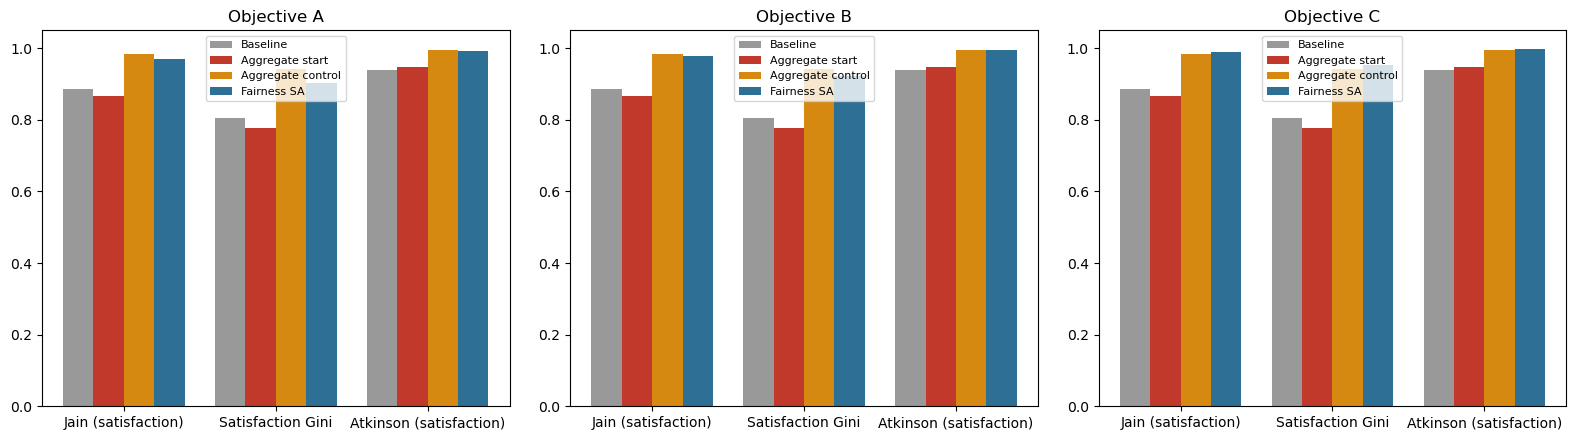

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = ["jain", "gini_satisfaction", "atkinson"]
labels = ["Jain (satisfaction)", "Satisfaction Gini", "Atkinson (satisfaction)"]

for ax, (name, result) in zip(axes, [("Objective A", result_A), ("Objective B", result_B), ("Objective C", result_C)]):
    baseline_vals = [result["baseline"][m] for m in metrics]
    agg_vals = [result["aggregate"][m] for m in metrics]
    control_vals = [result["aggregate_control"][m] for m in metrics]
    fair_vals = [result["fairness"][m] for m in metrics]
    x = range(len(metrics))
    width = 0.20

    # --Husain Naser update: show both equal-budget branches from the same Aggregate start.
    ax.bar([i - 1.5 * width for i in x], baseline_vals, width, label="Baseline", color="#999999")
    ax.bar([i - 0.5 * width for i in x], agg_vals, width, label="Aggregate start", color="#C0392B")
    ax.bar([i + 0.5 * width for i in x], control_vals, width, label="Aggregate control", color="#D68910")
    ax.bar([i + 1.5 * width for i in x], fair_vals, width, label="Fairness SA", color="#2E6F95")
    # ---end of mod: husain naser---

    ax.set_xticks(list(x)); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("aggregate_vs_fairness_comparison_v5.png", dpi=150)
plt.show()


## 9. Multi-seed equal-budget robustness

For each scattered seed, Stage 1 first creates a shared feasible timetable by optimizing
hard and logical constraints only. From that exact timetable, two Stage-2 continuations
receive the same additional iteration budget:

- **AGGREGATE_CONTROL:** optimizes mean burden only.
- **C_FAIRNESS:** optimizes Objective C.

Both continuations preserve 0 hard / 0 logical feasibility and otherwise use their
objective functions without additional human-impact guards.

Neither Stage-2 objective influences the shared starting timetable. This paired design
evaluates Objective C against mean-only Aggregate optimization for the same additional
budget. Jain, Atkinson and satisfaction-Gini are reported as validation diagnostics and do not gate the search.
Burden Gini is retained only for a degeneracy/confounding audit because it can behave pathologically as many burdens approach zero.
<!-- Husain Naser update: final metric-validity clarification; objectives remain unchanged. -->


In [14]:
# --Husain Naser update: use two seeds for the quick validation; set
# RUN_FULL_MULTI_SEED=True later to use the original ten-seed list.
validation_seeds = SEEDS if RUN_FULL_MULTI_SEED else SEEDS[:2]

robustness_rows = []
# --Husain Naser update: keep feasibility results for every seed, even when
# fairness refinement cannot be performed for an infeasible Aggregate start.
feasibility_rows = []
# ---end of mod: husain naser---
fairness_candidates = {}
aggregate_candidates = {}
aggregate_V_by_seed = {}
# --Husain Naser update: convergence checkpoints for the separate line-chart cell.
trajectory_rows = []
# ---end of mod: husain naser---

def percent_change(new, old):
    return 100 * (new - old) / old if abs(old) > 1e-12 else 0.0

for seed in validation_seeds:
    started = time.time()

    # --Husain Naser update: reuse the identical feasibility-only Stage-1 run from Section 8 when available.
    # Legacy aggregate_* result-field names are retained below to avoid unnecessary downstream changes.
    # ---end of mod: husain naser---
    cache_key = (seed, ROBUSTNESS_ITERATIONS)
    if cache_key in _FEASIBILITY_CACHE:
        aggregate_best, _, aggregate_accepted, _ = _FEASIBILITY_CACHE[cache_key]
    else:
        rng_aggregate = random.Random(seed)
        # --Husain Naser update: Stage 1 optimizes feasibility only.
        aggregate_best, _, aggregate_accepted, _ = sa_optimise(
            sessions,
            cost_feasibility_only,
            ROBUSTNESS_ITERATIONS,
            T0,
            ROBUSTNESS_COOLING,
            rng_aggregate,
        )
        # ---end of mod: husain naser---

    hard = count_hard_violations(aggregate_best)
    logical = count_logical_violations(aggregate_best)
    aggregate_metrics, aggregate_V, _ = burden_metrics(aggregate_best)

    # --Husain Naser update: report every Aggregate result instead of terminating
    # the complete experiment when one stochastic seed does not reach 0/0.
    aggregate_C_precheck = (
        0.40 * aggregate_metrics["mean"] / BASE_MEAN
        + 0.35 * aggregate_metrics["sd"] / BASE_SD
        + 0.25 * aggregate_metrics["top10"] / BASE_TOP10
    )

    aggregate_feasible = (hard == 0 and logical == 0)

    feasibility_rows.append({
        "seed": seed,
        "hard": hard,
        "logical": logical,
        "aggregate_feasible": aggregate_feasible,
        "mean": aggregate_metrics["mean"],
        "sd": aggregate_metrics["sd"],
        "top10": aggregate_metrics["top10"],
        "max": aggregate_metrics["max"],
        "C_score": aggregate_C_precheck,
        "gini_fairness": aggregate_metrics["gini_fairness"],
        "gini_satisfaction_fairness": aggregate_metrics["gini_satisfaction_fairness"],
        "accepted_moves": aggregate_accepted,
        "runtime_seconds": round(time.time() - started, 2),
    })

    if not aggregate_feasible:
        print(
            f"seed={seed:5d} objective={'FEASIBLE_START':18s} "
            f"hard={hard} logical={logical} "
            f"mean={aggregate_metrics['mean']:.4f} "
            f"sd={aggregate_metrics['sd']:.4f} "
            f"top10={aggregate_metrics['top10']:.4f} "
            f"max={aggregate_metrics['max']:.4f} "
            f"C={aggregate_C_precheck:.4f} "
            f"burden_gini={aggregate_metrics['gini_fairness']:.4f} "
            f"sat_gini={aggregate_metrics['gini_satisfaction_fairness']:.4f} "
            f"status=SKIPPED_FAIRNESS"
        )
        print(
            f"Seed {seed} was retained in the feasibility results, but fairness "
            f"refinement was skipped because the shared feasibility start was not 0/0."
        )
        continue
    # ---end of mod: husain naser---

    aggregate_candidates[seed] = aggregate_best
    aggregate_V_by_seed[seed] = aggregate_V

    # Equal-extra-budget control from the same timetable and random seed.
    aggregate_score = lambda metrics, V: metrics["mean"] / BASE_MEAN
    aggregate_control, control_info = sa_refine_feasible(
        aggregate_best,
        aggregate_score,
        STAGE2_ITERATIONS,
        random.Random(seed + 20000),
    )

    # --Husain Naser update: use the original explicit Objective C as the main
    # fairness-aware branch: 0.40 mean + 0.35 SD + 0.25 worst-10% (all normalized).
    # Lambda remains only for the optional sensitivity analysis, not the main run.
    fairness_score = lambda metrics, V: objective_soft_score(
        cost_objective_C_normalized_composite, metrics, V
    )
    # ---end of mod: husain naser---
    fairness_best, fairness_info = sa_refine_feasible(
        aggregate_best,
        fairness_score,
        STAGE2_ITERATIONS,
        random.Random(seed + 20000),
    )
    fairness_candidates[seed] = fairness_best

    fair_metrics = fairness_info["metrics"]
    control_metrics = control_info["metrics"]

    # --Husain Naser update: calculate the same feasibility and soft metrics for all
    # three schedules so the per-seed output is directly comparable.
    aggregate_hard = count_hard_violations(aggregate_best)
    aggregate_logical = count_logical_violations(aggregate_best)
    control_hard = count_hard_violations(aggregate_control)
    control_logical = count_logical_violations(aggregate_control)
    fair_hard = count_hard_violations(fairness_best)
    fair_logical = count_logical_violations(fairness_best)

    aggregate_C_score = fairness_score(aggregate_metrics, aggregate_V)
    control_C_score = fairness_score(control_metrics, control_info["V"])
    fair_C_score = fairness_score(fair_metrics, fairness_info["V"])
    # ---end of mod: husain naser---

    changes = tutor_change_summary(aggregate_V, fairness_info["V"])

    # --Husain Naser update: compare convergence on the original Objective C scale.
    # Both searches start from the same feasible Aggregate timetable, normalized to 1.0.
    for method_name, method_info in [
        ("Aggregate control", control_info),
        ("Fairness-aware C", fairness_info),
    ]:
        for checkpoint in method_info["trace"]:
            checkpoint_C = (
                0.40 * checkpoint["mean"] / BASE_MEAN
                + 0.35 * checkpoint["sd"] / BASE_SD
                + 0.25 * checkpoint["top10"] / BASE_TOP10
            )
            # --Husain Naser update: keep the existing common-C trajectory, but also
            # store each arm's OWN optimized score, normalized to its value at iteration 0.
            # This is the correct convergence check before interpreting any weight sweep:
            # Aggregate optimizes mean, whereas Objective C optimizes the explicit composite C.
            own_start_score = max(method_info["trace"][0]["search_score"], 1e-12)
            trajectory_rows.append({
                "seed": seed,
                "method": method_name,
                "iteration": checkpoint["iteration"],
                "normalized_C": checkpoint_C / max(aggregate_C_score, 1e-12),
                "normalized_own_objective": checkpoint["search_score"] / own_start_score,
                "normalized_mean": checkpoint["mean"] / max(aggregate_metrics["mean"], 1e-12),
                "normalized_sd": checkpoint["sd"] / max(aggregate_metrics["sd"], 1e-12),
                "normalized_top10": checkpoint["top10"] / max(aggregate_metrics["top10"], 1e-12),
            })
            # ---end of mod: husain naser---
    # ---end of mod: husain naser---

    row = {
        "seed": seed,

        "aggregate_hard": aggregate_hard,
        "aggregate_logical": aggregate_logical,
        "aggregate_control_hard": control_hard,
        "aggregate_control_logical": control_logical,
        "hard": fair_hard,
        "logical": fair_logical,

        "aggregate_mean": aggregate_metrics["mean"],
        "aggregate_control_mean": control_metrics["mean"],
        "fair_mean": fair_metrics["mean"],
        "mean_change_pct": percent_change(fair_metrics["mean"], aggregate_metrics["mean"]),
        "mean_change_vs_control_pct": percent_change(
            fair_metrics["mean"], control_metrics["mean"]
        ),

        "aggregate_sd": aggregate_metrics["sd"],
        "aggregate_control_sd": control_metrics["sd"],
        "fair_sd": fair_metrics["sd"],
        "sd_change_pct": percent_change(fair_metrics["sd"], aggregate_metrics["sd"]),
        "sd_change_vs_control_pct": percent_change(
            fair_metrics["sd"], control_metrics["sd"]
        ),

        "aggregate_top10": aggregate_metrics["top10"],
        "aggregate_control_top10": control_metrics["top10"],
        "fair_top10": fair_metrics["top10"],
        "top10_change_pct": percent_change(fair_metrics["top10"], aggregate_metrics["top10"]),
        "top10_change_vs_control_pct": percent_change(
            fair_metrics["top10"], control_metrics["top10"]
        ),

        "aggregate_max": aggregate_metrics["max"],
        "aggregate_control_max": control_metrics["max"],
        "fair_max": fair_metrics["max"],
        "max_change_pct": percent_change(fair_metrics["max"], aggregate_metrics["max"]),

        "aggregate_gini_fairness": aggregate_metrics["gini_fairness"],
        "aggregate_control_gini_fairness": control_metrics["gini_fairness"],
        "fair_gini_fairness": fair_metrics["gini_fairness"],
        "gini_fairness_change_pct": percent_change(
            fair_metrics["gini_fairness"],
            aggregate_metrics["gini_fairness"],
        ),
        # --Husain Naser update: paired Gini burden-equality change versus the equal-budget control.
        "gini_fairness_change_vs_control_pct": percent_change(
            fair_metrics["gini_fairness"],
            control_metrics["gini_fairness"],
        ),
        # ---end of mod: husain naser---

        # --Husain Naser update: satisfaction-Gini is the post-hoc metric-validity
        # check requested after burden-Gini was found to track mean burden too closely.
        # It is reporting-only and does not alter either SA trajectory.
        "aggregate_gini_satisfaction_fairness": aggregate_metrics["gini_satisfaction_fairness"],
        "aggregate_control_gini_satisfaction_fairness": control_metrics["gini_satisfaction_fairness"],
        "fair_gini_satisfaction_fairness": fair_metrics["gini_satisfaction_fairness"],
        "gini_satisfaction_change_vs_control_pct": percent_change(
            fair_metrics["gini_satisfaction_fairness"],
            control_metrics["gini_satisfaction_fairness"],
        ),
        # ---end of mod: husain naser---

        "aggregate_C_score": aggregate_C_score,
        "aggregate_control_C_score": control_C_score,
        "fair_C_score": fair_C_score,
        "C_score_change_vs_control_pct": percent_change(
            fair_C_score, control_C_score
        ),

        "aggregate_accepted_moves": aggregate_accepted,
        "fairness_accepted_moves": fairness_info["accepted_moves"],
        **changes,
        "runtime_seconds": round(time.time() - started, 2),
    }

    # --Husain Naser update: rename the old strict pass/fail field so it is not
    # misread as the definition of "fairness". This remains a conservative
    # all-primary-metrics dominance diagnostic; Gini/Jain/Atkinson stay separate.
    row["all_metrics_dominance"] = (
        row["aggregate_hard"] == 0
        and row["aggregate_logical"] == 0
        and row["aggregate_control_hard"] == 0
        and row["aggregate_control_logical"] == 0
        and row["hard"] == 0
        and row["logical"] == 0
        and row["fair_mean"] <= row["aggregate_control_mean"] + 1e-12
        and row["fair_sd"] < row["aggregate_control_sd"] - 1e-12
        and row["fair_top10"] < row["aggregate_control_top10"] - 1e-12
        and row["fair_max"] <= row["aggregate_max"] + 1e-12
        and row["fair_C_score"]
            < row["aggregate_control_C_score"] - 1e-12
    )
    # ---end of mod: husain naser---
    robustness_rows.append(row)

    # --Husain Naser update: print hard/logical counts and all common metrics for
    # the shared start, the equal-budget control, and the fairness-aware candidate.
    print(
        f"seed={seed:5d} objective={'FEASIBLE_START':18s} "
        f"hard={row['aggregate_hard']} logical={row['aggregate_logical']} "
        f"mean={row['aggregate_mean']:.4f} sd={row['aggregate_sd']:.4f} "
        f"top10={row['aggregate_top10']:.4f} max={row['aggregate_max']:.4f} "
        f"C={row['aggregate_C_score']:.4f} burden_gini={row['aggregate_gini_fairness']:.4f} "
        f"sat_gini={row['aggregate_gini_satisfaction_fairness']:.4f}"
    )
    print(
        f"seed={seed:5d} objective={'AGGREGATE_CONTROL':18s} "
        f"hard={row['aggregate_control_hard']} logical={row['aggregate_control_logical']} "
        f"mean={row['aggregate_control_mean']:.4f} sd={row['aggregate_control_sd']:.4f} "
        f"top10={row['aggregate_control_top10']:.4f} max={row['aggregate_control_max']:.4f} "
        f"C={row['aggregate_control_C_score']:.4f} "
        f"burden_gini={row['aggregate_control_gini_fairness']:.4f} "
        f"sat_gini={row['aggregate_control_gini_satisfaction_fairness']:.4f}"
    )
    print(
        f"seed={seed:5d} objective={'C_FAIRNESS':18s} "
        f"hard={row['hard']} logical={row['logical']} "
        f"mean={row['fair_mean']:.4f} sd={row['fair_sd']:.4f} "
        f"top10={row['fair_top10']:.4f} max={row['fair_max']:.4f} "
        f"C={row['fair_C_score']:.4f} burden_gini={row['fair_gini_fairness']:.4f} "
        f"sat_gini={row['fair_gini_satisfaction_fairness']:.4f} "
        f"all_metrics_dominance={row['all_metrics_dominance']}"
    )
    # ---end of mod: husain naser---

# --Husain Naser update: report feasibility separately from fairness performance.
feasibility_df = pd.DataFrame(feasibility_rows)

aggregate_feasible_count = int(feasibility_df["aggregate_feasible"].sum())
tested_seed_count = len(feasibility_df)

print()
print("--- Aggregate feasibility across all seeds ---")
print(feasibility_df.to_string(index=False))
print(
    f"\nAggregate feasibility: "
    f"{aggregate_feasible_count}/{tested_seed_count} seeds reached 0 hard / 0 logical."
)

feasibility_df.to_csv(
    "aggregate_feasibility_by_seed_v5.csv",
    index=False,
)
# ---end of mod: husain naser---

robustness_df = pd.DataFrame(robustness_rows)

print(
    f"Valid paired fairness comparisons: "
    f"{len(robustness_df)}/{tested_seed_count} seeds."
)

dominance_count = int(robustness_df["all_metrics_dominance"].sum())
print(
    f"Strict secondary all-metrics dominance: "
    f"{dominance_count}/{len(robustness_df)} valid paired seeds."
)

print()
print("--- Fairness-aware validation (equal-budget, no human-impact guards) ---")
# --Husain Naser update: keep tutor-worsening audit fields in robustness_df/CSV,
# but omit the two detailed tutor-level fields from the main printed table for readability.
main_results_df = robustness_df.drop(
    columns=["tutors_worsened", "max_individual_deterioration"],
    errors="ignore",
)
print(main_results_df.to_string(index=False))
# ---end of mod: husain naser---
print()
print("--- Mean percentage changes: fairness-aware vs equal-budget Aggregate control ---")
print(
    robustness_df[
        ["mean_change_vs_control_pct", "sd_change_vs_control_pct",
         "top10_change_vs_control_pct", "C_score_change_vs_control_pct",
         "gini_fairness_change_vs_control_pct",
         "gini_satisfaction_change_vs_control_pct"]
    ].mean().to_string()
)
print(
    "\nMaximum-burden change is measured against the shared feasible Aggregate start: "
    f"{robustness_df['max_change_pct'].mean():.4f}% on average."
)

# --Husain Naser update: describe the strict diagnostic as dominance, not as
# proof that fairness is or is not "supported".
if not robustness_df.empty and robustness_df["all_metrics_dominance"].all():
    print(
        "\nObjective C achieved strict all-metrics dominance on every valid paired seed. "
        "This remains a secondary diagnostic, not the study success criterion."
    )
else:
    print(
        "\nStrict all-metrics dominance was not universal. This is a secondary diagnostic only; "
        "interpret the paired efficiency and fairness outcomes separately."
    )
# ---end of mod: husain naser---

robustness_df.to_csv("seed_robustness_table_v5.csv", index=False)

# --Husain Naser update: keep the convergence data available to the separate chart cell.
trajectory_df = pd.DataFrame(trajectory_rows)
trajectory_df.to_csv("fairness_convergence_trace_v5.csv", index=False)
# ---end of mod: husain naser---


seed=   42 objective=FEASIBLE_START     hard=0 logical=0 mean=0.3390 sd=0.2592 top10=0.7860 max=1.0000 C=1.0778 burden_gini=0.5644 sat_gini=0.7766
seed=   42 objective=AGGREGATE_CONTROL  hard=0 logical=0 mean=0.0716 sd=0.1157 top10=0.3472 max=0.5000 C=0.3668 burden_gini=0.2524 sat_gini=0.9423
seed=   42 objective=C_FAIRNESS         hard=0 logical=0 mean=0.0602 sd=0.0926 top10=0.2755 max=0.3334 C=0.2970 burden_gini=0.2674 sat_gini=0.9531 all_metrics_dominance=True
seed=   47 objective=FEASIBLE_START     hard=0 logical=0 mean=0.3225 sd=0.2435 top10=0.7639 max=1.0000 C=1.0263 burden_gini=0.5766 sat_gini=0.7985
seed=   47 objective=AGGREGATE_CONTROL  hard=0 logical=0 mean=0.0519 sd=0.0929 top10=0.2844 max=0.4445 C=0.2884 burden_gini=0.2198 sat_gini=0.9573
seed=   47 objective=C_FAIRNESS         hard=0 logical=0 mean=0.0764 sd=0.1107 top10=0.3171 max=0.5000 C=0.3575 burden_gini=0.2943 sat_gini=0.9417 all_metrics_dominance=False
seed=   59 objective=FEASIBLE_START     hard=0 logical=1 mean=0

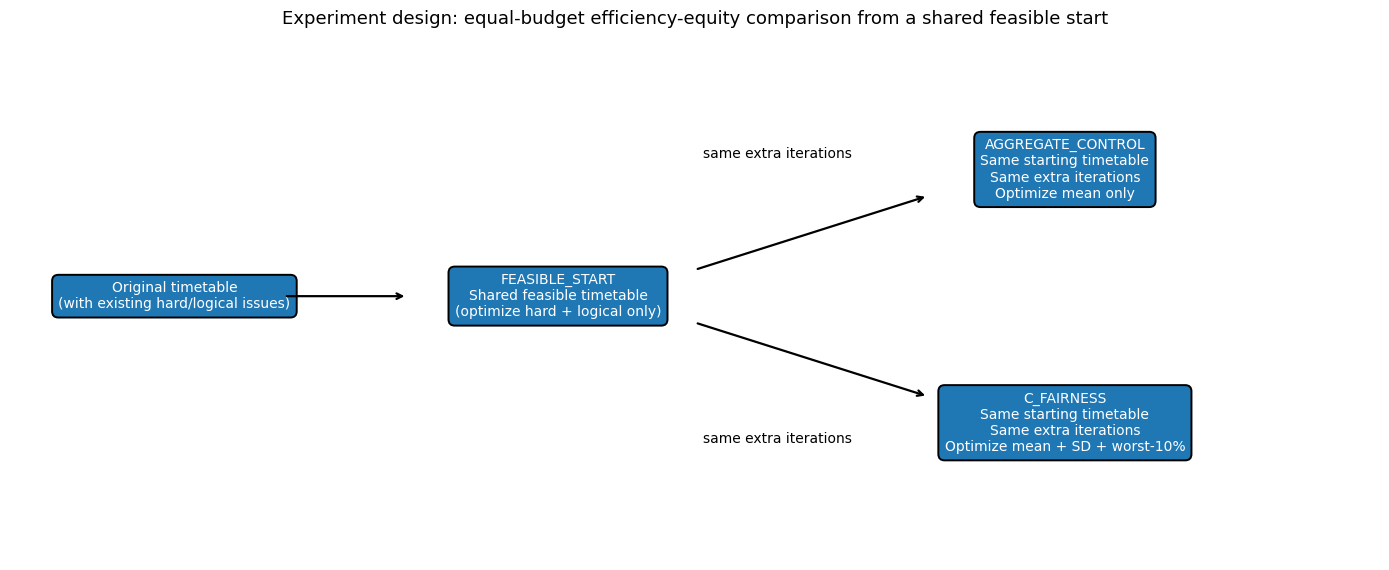

Stage 1 creates a neutral feasible timetable. Stage 2 compares equal-budget mean-only efficiency with fairness-aware Objective C from that identical start; mean dominance is not required for a fairness trade-off.


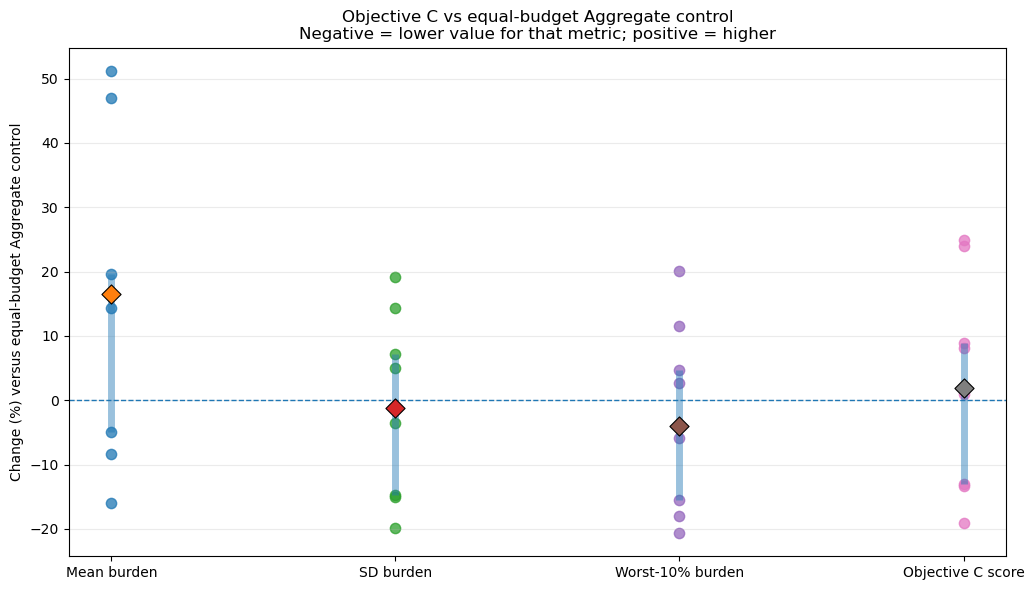


Objective C vs Aggregate control summary:
                                  Metric  Average change %  Median change %  Seeds improved  Total seeds  Wilcoxon p
                             Mean burden         15.109341        16.543997               3            9    0.128906
                               SD burden         -0.973752        -1.143099               5            9    0.820312
                        Worst-10% burden         -2.795968        -4.059515               5            9    0.570312
                       Objective C score          2.571526         1.919217               3            9    0.734375
Burden Gini (1-G; confounded diagnostic)         22.515212        21.924721               9            9    0.003906
 Satisfaction Gini (1-G; validity check)         -0.357076        -0.441900               3            9    0.496094

How to read this:
- Mean burden is the efficiency metric; a fairness-aware objective is not required to beat a mean-only optimizer on mea

In [15]:
########## FIRST PLOT: EXPERIMENT DESIGN FLOWCHART ##########

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Darker box style so white text is readable
box_style = dict(
    boxstyle="round,pad=0.45",
    facecolor="#1f77b4",
    edgecolor="black",
    linewidth=1.4,
)

text_style = dict(
    ha="center",
    va="center",
    color="white",
    fontsize=10,
)

# Box centers
start_xy = (0.12, 0.50)
agg_start_xy = (0.40, 0.50)
agg_control_xy = (0.77, 0.74)
fair_xy = (0.77, 0.26)

# Draw boxes
ax.text(
    *start_xy,
    "Original timetable\n(with existing hard/logical issues)",
    bbox=box_style,
    **text_style
)

ax.text(
    *agg_start_xy,
    "FEASIBLE_START\nShared feasible timetable\n(optimize hard + logical only)",
    bbox=box_style,
    **text_style
)

ax.text(
    *agg_control_xy,
    "AGGREGATE_CONTROL\nSame starting timetable\nSame extra iterations\nOptimize mean only",
    bbox=box_style,
    **text_style
)

ax.text(
    *fair_xy,
    "C_FAIRNESS\nSame starting timetable\nSame extra iterations\nOptimize mean + SD + worst-10%",
    bbox=box_style,
    **text_style
)

# Arrows: connect edge-to-edge more cleanly
arrow_style = dict(arrowstyle="->", linewidth=1.6, color="black")

# Original -> Aggregate start
ax.annotate(
    "",
    xy=(0.29, 0.50),
    xytext=(0.20, 0.50),
    arrowprops=arrow_style
)

# Aggregate start -> Aggregate control
ax.annotate(
    "",
    xy=(0.67, 0.69),
    xytext=(0.50, 0.55),
    arrowprops=arrow_style
)

# Aggregate start -> Fairness
ax.annotate(
    "",
    xy=(0.67, 0.31),
    xytext=(0.50, 0.45),
    arrowprops=arrow_style
)

# Arrow labels placed away from boxes/arrows
ax.text(0.56, 0.77, "same extra iterations", fontsize=10, ha="center", va="center")
ax.text(0.56, 0.23, "same extra iterations", fontsize=10, ha="center", va="center")

ax.set_title(
    "Experiment design: equal-budget efficiency-equity comparison from a shared feasible start",
    fontsize=13
)

plt.tight_layout()
plt.show()

print("Stage 1 creates a neutral feasible timetable. Stage 2 compares equal-budget mean-only efficiency with fairness-aware Objective C from that identical start; mean dominance is not required for a fairness trade-off.")

################ SECOND PLOT: FAIRNESS-AWARE VS EQUAL-BUDGET AGGREGATE CONTROL ################

import matplotlib.pyplot as plt
import pandas as pd

# Keep only valid paired comparisons
plot_df = robustness_df.copy()

# If you want to be extra safe, keep only rows where all three schedules were feasible
plot_df = plot_df[
    (plot_df["aggregate_hard"] == 0)
    & (plot_df["aggregate_logical"] == 0)
    & (plot_df["aggregate_control_hard"] == 0)
    & (plot_df["aggregate_control_logical"] == 0)
    & (plot_df["hard"] == 0)
    & (plot_df["logical"] == 0)
].copy()

if plot_df.empty:
    print("No valid paired seeds found.")
else:
    metric_map = [
        ("Mean burden", "mean_change_vs_control_pct"),
        ("SD burden", "sd_change_vs_control_pct"),
        ("Worst-10% burden", "top10_change_vs_control_pct"),
        ("Objective C score", "C_score_change_vs_control_pct"),
    ]

    fig, ax = plt.subplots(figsize=(10.5, 6))

    # one point per seed, plus median marker
    for i, (label, col) in enumerate(metric_map):
        y = plot_df[col].astype(float).values
        x = [i] * len(y)

        ax.scatter(x, y, s=55, alpha=0.75)

        median_y = pd.Series(y).median()
        q1 = pd.Series(y).quantile(0.25)
        q3 = pd.Series(y).quantile(0.75)

        ax.vlines(i, q1, q3, linewidth=5, alpha=0.45)
        ax.scatter(i, median_y, marker="D", s=95, edgecolors="black", linewidths=0.8, zorder=3)

    ax.axhline(0, linewidth=1, linestyle="--")
    ax.set_xticks(range(len(metric_map)))
    ax.set_xticklabels([m[0] for m in metric_map])
    ax.set_ylabel("Change (%) versus equal-budget Aggregate control")
    ax.set_title(
        "Objective C vs equal-budget Aggregate control\n"
        "Negative = lower value for that metric; positive = higher"
    )
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    # --Husain Naser update: FINAL metric-validity summary. Burden Gini is retained
    # only as a confounded diagnostic; satisfaction Gini is the post-hoc validity check.
    # Neither Gini measure was optimized.
    summary_specs = [
        ("Mean burden", "mean_change_vs_control_pct",
         "aggregate_control_mean", "fair_mean", "lower"),
        ("SD burden", "sd_change_vs_control_pct",
         "aggregate_control_sd", "fair_sd", "lower"),
        ("Worst-10% burden", "top10_change_vs_control_pct",
         "aggregate_control_top10", "fair_top10", "lower"),
        ("Objective C score", "C_score_change_vs_control_pct",
         "aggregate_control_C_score", "fair_C_score", "lower"),
        ("Burden Gini (1-G; confounded diagnostic)", "gini_fairness_change_vs_control_pct",
         "aggregate_control_gini_fairness", "fair_gini_fairness", "higher"),
        ("Satisfaction Gini (1-G; validity check)", "gini_satisfaction_change_vs_control_pct",
         "aggregate_control_gini_satisfaction_fairness",
         "fair_gini_satisfaction_fairness", "higher"),
    ]

    summary_rows = []
    for label, pct_col, control_col, fair_col, better_direction in summary_specs:
        paired = plot_df[[control_col, fair_col]].dropna()
        differences = paired[fair_col] - paired[control_col]
        if len(paired) > 0 and (differences.abs() > 1e-12).any():
            p_value = float(
                wilcoxon(
                    paired[fair_col],
                    paired[control_col],
                    alternative="two-sided",
                    method="auto",
                ).pvalue
            )
        else:
            p_value = 1.0

        improved = (
            (plot_df[pct_col] < 0).sum()
            if better_direction == "lower"
            else (plot_df[pct_col] > 0).sum()
        )

        summary_rows.append({
            "Metric": label,
            "Average change %": plot_df[pct_col].mean(),
            "Median change %": plot_df[pct_col].median(),
            "Seeds improved": int(improved),
            "Total seeds": len(plot_df),
            "Wilcoxon p": p_value,
        })

    summary = pd.DataFrame(summary_rows)

    print("\nObjective C vs Aggregate control summary:")
    print(summary.to_string(index=False))

    print("\nHow to read this:")
    print("- Mean burden is the efficiency metric; a fairness-aware objective is not required to beat a mean-only optimizer on mean.")
    print("- SD and worst-10% are absolute burden-dispersion outcomes and remain correlated with mean burden.")
    print("- Burden Gini is retained only to document its near-zero degeneracy/confounding; do not use it as headline evidence.")
    print("- Satisfaction Gini applies 1-Gini to satisfaction = 1-burden and is the final reporting-only validity check.")
    print("- Satisfaction Gini was added after the burden-Gini confound was identified; interpret it transparently as a metric-validity check, not a tuned objective.")
    print("- Strict all-metrics dominance is only a secondary diagnostic, not the study success criterion.")
    print("- Objective C score remains the legacy pre-specified composite diagnostic.")
    # ---end of mod: husain naser---


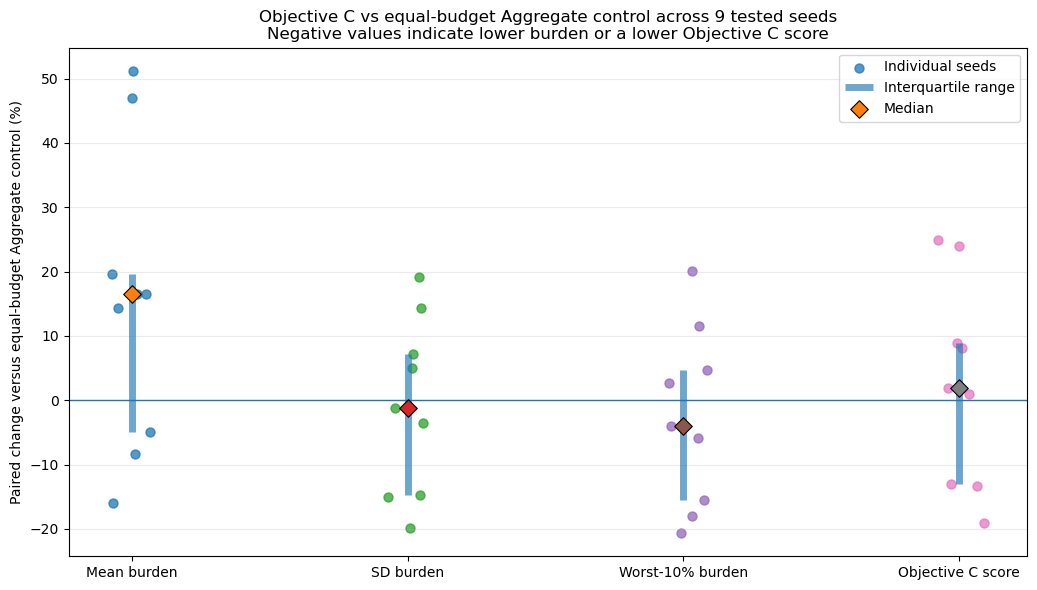

Satisfaction-Gini is reported separately in the statistical summary above (higher is better).


In [16]:
# --Husain Naser update: primary across-seed evidence chart.
# One dot is one paired seed result. The diamond is the median and the thick
# vertical segment is the interquartile range. Values below zero are improvements.
metric_columns = [
    ("Mean burden", "mean_change_vs_control_pct"),
    ("SD burden", "sd_change_vs_control_pct"),
    ("Worst-10% burden", "top10_change_vs_control_pct"),
    ("Objective C score", "C_score_change_vs_control_pct"),
]

jitter_rng = random.Random(2026)
fig, ax = plt.subplots(figsize=(10.5, 6))

for metric_index, (metric_label, column_name) in enumerate(metric_columns):
    values = robustness_df[column_name].dropna().astype(float)
    jittered_x = [
        metric_index + jitter_rng.uniform(-0.09, 0.09)
        for _ in range(len(values))
    ]

    ax.scatter(
        jittered_x,
        values,
        s=42,
        alpha=0.75,
        label="Individual seeds" if metric_index == 0 else None,
    )

    q1 = values.quantile(0.25)
    median = values.median()
    q3 = values.quantile(0.75)

    ax.vlines(
        metric_index,
        q1,
        q3,
        linewidth=5,
        alpha=0.65,
        label="Interquartile range" if metric_index == 0 else None,
    )
    ax.scatter(
        [metric_index],
        [median],
        marker="D",
        s=80,
        edgecolors="black",
        linewidths=0.8,
        zorder=3,
        label="Median" if metric_index == 0 else None,
    )

ax.axhline(0, linewidth=1)
ax.set_xticks(range(len(metric_columns)))
ax.set_xticklabels([label for label, _ in metric_columns])
ax.set_ylabel("Paired change versus equal-budget Aggregate control (%)")
ax.set_title(
    f"Objective C vs equal-budget Aggregate control across {len(robustness_df)} tested seeds\n"
    "Negative values indicate lower burden or a lower Objective C score"
)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("fairness_across_seed_distribution_v5.png", dpi=300, bbox_inches="tight")
plt.show()
# ---end of mod: husain naser---

# --Husain Naser update: satisfaction-Gini is intentionally not mixed into this
# lower-is-better burden chart. Its paired row and p-value are reported in the summary
# above, where higher-is-better semantics are handled correctly.
print("Satisfaction-Gini is reported separately in the statistical summary above (higher is better).")
# ---end of mod: husain naser---


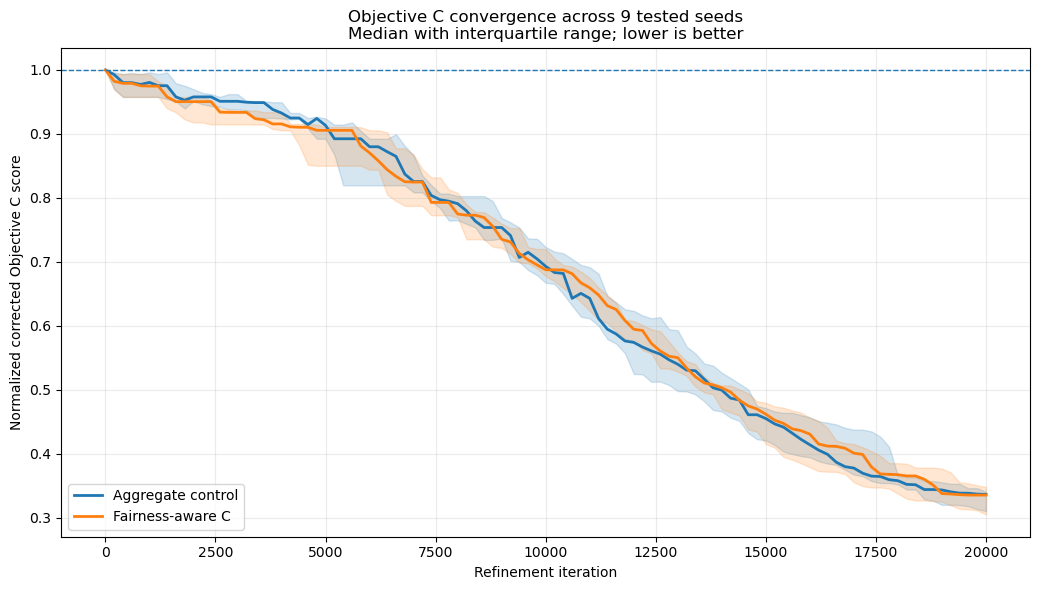

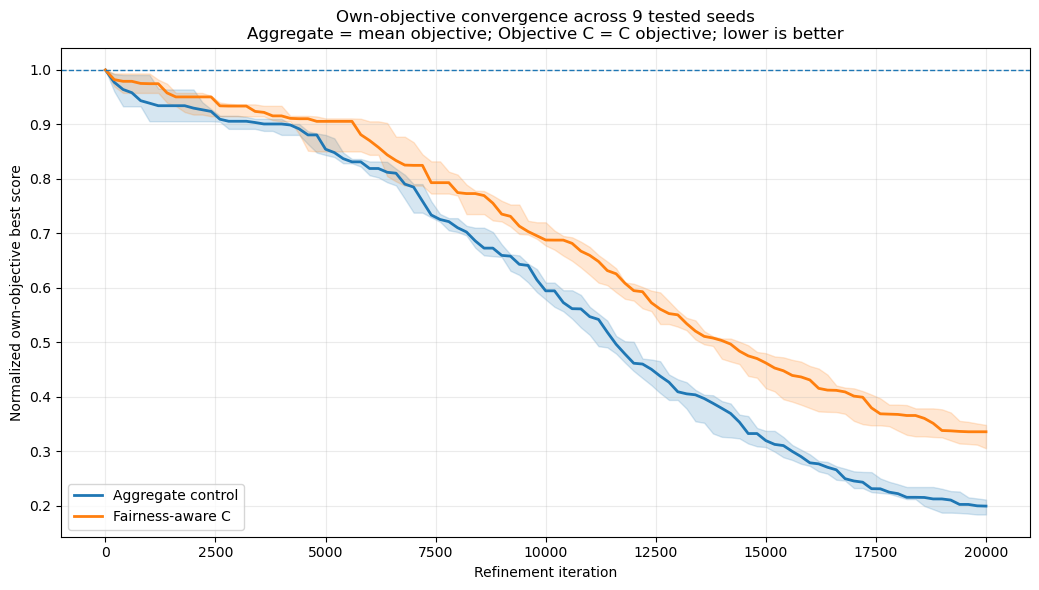

Fixed-budget limitation: the 20,000-iteration Stage-2 runs are treated as an equal-budget comparison, not as proof of numerical convergence. The study therefore reports paired outcomes at the frozen budget and does not keep tuning the iteration count after seeing the results.


In [17]:
# --Husain Naser update: convergence of the two equal-budget refinements.
# The line is the median across seeds and the shaded band is the interquartile range.
# Each seed is normalized to its own shared feasibility-only start (= 1.0).
fig, ax = plt.subplots(figsize=(10.5, 6))

for method_name, method_data in trajectory_df.groupby("method", sort=False):
    summary = (
        method_data.groupby("iteration")["normalized_C"]
        .agg(
            median="median",
            q1=lambda values: values.quantile(0.25),
            q3=lambda values: values.quantile(0.75),
        )
        .reset_index()
    )

    line, = ax.plot(
        summary["iteration"],
        summary["median"],
        linewidth=2,
        label=method_name,
    )
    ax.fill_between(
        summary["iteration"],
        summary["q1"],
        summary["q3"],
        alpha=0.18,
        color=line.get_color(),
    )

ax.axhline(1.0, linewidth=1, linestyle="--")
ax.set_xlabel("Refinement iteration")
ax.set_ylabel("Normalized corrected Objective C score")
ax.set_title(
    f"Objective C convergence across {len(robustness_df)} tested seeds\n"
    "Median with interquartile range; lower is better"
)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("fairness_objective_C_convergence_v5.png", dpi=300, bbox_inches="tight")
plt.show()
# ---end of mod: husain naser---


# --Husain Naser update: budget check on EACH arm's own optimized objective.
# The plot above is still useful because it puts both methods on the common Objective-C scale.
# This second plot answers the different question "has each SA run itself flattened yet?"
# It must be checked before interpreting the lambda sensitivity experiment below.
#
# Literature context: Mühlenthaler & Wanka (2016) evaluate fairness and total-penalty
# performance as competing criteria using simulated annealing. For our comparison to be
# meaningful, both arms should first be given an adequate and equal search budget.
fig, ax = plt.subplots(figsize=(10.5, 6))

for method_name, method_data in trajectory_df.groupby("method", sort=False):
    own_summary = (
        method_data.groupby("iteration")["normalized_own_objective"]
        .agg(
            median="median",
            q1=lambda values: values.quantile(0.25),
            q3=lambda values: values.quantile(0.75),
        )
        .reset_index()
    )

    line, = ax.plot(
        own_summary["iteration"],
        own_summary["median"],
        linewidth=2,
        label=method_name,
    )
    ax.fill_between(
        own_summary["iteration"],
        own_summary["q1"],
        own_summary["q3"],
        alpha=0.18,
        color=line.get_color(),
    )

ax.axhline(1.0, linewidth=1, linestyle="--")
ax.set_xlabel("Refinement iteration")
ax.set_ylabel("Normalized own-objective best score")
ax.set_title(
    f"Own-objective convergence across {len(robustness_df)} tested seeds\n"
    "Aggregate = mean objective; Objective C = C objective; lower is better"
)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("own_objective_convergence_v5.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    "Fixed-budget limitation: the 20,000-iteration Stage-2 runs are treated as an "
    "equal-budget comparison, not as proof of numerical convergence. The study "
    "therefore reports paired outcomes at the frozen budget and does not keep tuning "
    "the iteration count after seeing the results."
)
# ---end of mod: husain naser---


### 9.1 Pre-registered equity-only endpoint check

This is a **single, final robustness variant**, not a replacement for the pre-specified
Objective C result above. It selects the already-defined `lambda = 0.0` endpoint of
`objective_C_lambda_score`, so the fairness search optimizes only the two existing
equity terms while preserving their original 0.35:0.25 ratio:

`C_equity = (7/12) * normalized_SD + (5/12) * normalized_worst10`.

**Decision frozen before execution:** compare SD and worst-10% against the same
equal-budget mean-only control using the same valid seeds and 20,000 Stage-2 iterations.
Mean burden is reported as the efficiency price. Gini burden-equality (1-G) is an
independent scale-invariant outcome and is not optimized. Regardless of the result,
**no further objective reweighting or tuning will be performed**. If this endpoint does
not improve the fairness outcomes reliably, that is reported as a negative empirical
finding and the original pre-specified composite result remains the main study result.

<!-- Husain Naser update: pre-registered before executing the equity-only endpoint. -->


In [18]:
# --Husain Naser update: one final equity-only endpoint test.
# It reuses the existing lambda parameterization at lambda=0.0. The Aggregate
# control is NOT rerun; the already-computed equal-budget control is reused.
equity_only_rows = []
equity_only_candidates = {}

equity_only_score = lambda metrics, V: objective_C_lambda_score(metrics, 0.0)

for _, base_row in robustness_df.iterrows():
    seed = int(base_row["seed"])
    shared_start = aggregate_candidates[seed]

    equity_best, equity_info = sa_refine_feasible(
        shared_start,
        equity_only_score,
        STAGE2_ITERATIONS,
        random.Random(seed + 20000),
    )

    if (
        count_hard_violations(equity_best) != 0
        or count_logical_violations(equity_best) != 0
    ):
        raise RuntimeError(
            f"equity-only seed={seed}: feasible refinement left the 0/0 region."
        )

    equity_only_candidates[seed] = equity_best
    m = equity_info["metrics"]

    control_equity_score = objective_C_lambda_score({
        "mean": base_row["aggregate_control_mean"],
        "sd": base_row["aggregate_control_sd"],
        "top10": base_row["aggregate_control_top10"],
    }, 0.0)
    candidate_equity_score = objective_C_lambda_score(m, 0.0)

    control_legacy_C = objective_C_lambda_score({
        "mean": base_row["aggregate_control_mean"],
        "sd": base_row["aggregate_control_sd"],
        "top10": base_row["aggregate_control_top10"],
    }, 0.40)
    candidate_legacy_C = objective_C_lambda_score(m, 0.40)

    equity_only_rows.append({
        "seed": seed,
        "control_mean": float(base_row["aggregate_control_mean"]),
        "equity_mean": float(m["mean"]),
        "mean_change_pct": percent_change(
            float(m["mean"]), float(base_row["aggregate_control_mean"])
        ),
        "control_sd": float(base_row["aggregate_control_sd"]),
        "equity_sd": float(m["sd"]),
        "sd_change_pct": percent_change(
            float(m["sd"]), float(base_row["aggregate_control_sd"])
        ),
        "control_top10": float(base_row["aggregate_control_top10"]),
        "equity_top10": float(m["top10"]),
        "top10_change_pct": percent_change(
            float(m["top10"]), float(base_row["aggregate_control_top10"])
        ),
        "control_gini_burden_equality": float(base_row["aggregate_control_gini_fairness"]),
        "equity_gini_burden_equality": float(m["gini_fairness"]),
        "gini_burden_equality_change_pct": percent_change(
            float(m["gini_fairness"]),
            float(base_row["aggregate_control_gini_fairness"]),
        ),
        # --Husain Naser update: satisfaction-Gini validity check; reporting-only.
        "control_gini_satisfaction_fairness": float(base_row["aggregate_control_gini_satisfaction_fairness"]),
        "equity_gini_satisfaction_fairness": float(m["gini_satisfaction_fairness"]),
        "gini_satisfaction_change_pct": percent_change(
            float(m["gini_satisfaction_fairness"]),
            float(base_row["aggregate_control_gini_satisfaction_fairness"]),
        ),
        # ---end of mod: husain naser---
        "control_equity_score": float(control_equity_score),
        "equity_score": float(candidate_equity_score),
        "equity_score_change_pct": percent_change(
            float(candidate_equity_score), float(control_equity_score)
        ),
        "control_legacy_C": float(control_legacy_C),
        "equity_legacy_C": float(candidate_legacy_C),
    })

    print(
        f"seed={seed:5d} objective={'EQUITY_ONLY_C':18s} "
        f"mean={m['mean']:.4f} sd={m['sd']:.4f} "
        f"top10={m['top10']:.4f} "
        f"burden_gini_diag={m['gini_fairness']:.4f} "
        f"sat_gini={m['gini_satisfaction_fairness']:.4f} "
        f"equity_score={candidate_equity_score:.4f}"
    )

equity_only_df = pd.DataFrame(equity_only_rows)
equity_only_df.to_csv("objective_C_equity_only_endpoint_v5.csv", index=False)


def paired_wilcoxon_p(df, control_col, candidate_col):
    paired = df[[control_col, candidate_col]].dropna()
    diffs = paired[candidate_col] - paired[control_col]
    if len(paired) == 0 or not (diffs.abs() > 1e-12).any():
        return 1.0
    return float(
        wilcoxon(
            paired[candidate_col],
            paired[control_col],
            alternative="two-sided",
            method="auto",
        ).pvalue
    )

equity_summary = pd.DataFrame([
    {
        "Metric": "Mean burden (efficiency price)",
        "Average change %": equity_only_df["mean_change_pct"].mean(),
        "Median change %": equity_only_df["mean_change_pct"].median(),
        "Seeds improved": int((equity_only_df["mean_change_pct"] < 0).sum()),
        "Total seeds": len(equity_only_df),
        "Wilcoxon p": paired_wilcoxon_p(
            equity_only_df, "control_mean", "equity_mean"
        ),
    },
    {
        "Metric": "SD burden (primary fairness outcome)",
        "Average change %": equity_only_df["sd_change_pct"].mean(),
        "Median change %": equity_only_df["sd_change_pct"].median(),
        "Seeds improved": int((equity_only_df["sd_change_pct"] < 0).sum()),
        "Total seeds": len(equity_only_df),
        "Wilcoxon p": paired_wilcoxon_p(
            equity_only_df, "control_sd", "equity_sd"
        ),
    },
    {
        "Metric": "Worst-10% burden (primary fairness outcome)",
        "Average change %": equity_only_df["top10_change_pct"].mean(),
        "Median change %": equity_only_df["top10_change_pct"].median(),
        "Seeds improved": int((equity_only_df["top10_change_pct"] < 0).sum()),
        "Total seeds": len(equity_only_df),
        "Wilcoxon p": paired_wilcoxon_p(
            equity_only_df, "control_top10", "equity_top10"
        ),
    },
    {
        "Metric": "Burden Gini (1-G; confounded diagnostic)",
        "Average change %": equity_only_df["gini_burden_equality_change_pct"].mean(),
        "Median change %": equity_only_df["gini_burden_equality_change_pct"].median(),
        "Seeds improved": int((equity_only_df["gini_burden_equality_change_pct"] > 0).sum()),
        "Total seeds": len(equity_only_df),
        "Wilcoxon p": paired_wilcoxon_p(
            equity_only_df,
            "control_gini_burden_equality",
            "equity_gini_burden_equality",
        ),
    },
    {
        "Metric": "Satisfaction Gini (1-G; validity check)",
        "Average change %": equity_only_df["gini_satisfaction_change_pct"].mean(),
        "Median change %": equity_only_df["gini_satisfaction_change_pct"].median(),
        "Seeds improved": int((equity_only_df["gini_satisfaction_change_pct"] > 0).sum()),
        "Total seeds": len(equity_only_df),
        "Wilcoxon p": paired_wilcoxon_p(
            equity_only_df,
            "control_gini_satisfaction_fairness",
            "equity_gini_satisfaction_fairness",
        ),
    },
    {
        "Metric": "Equity-only score (optimized target)",
        "Average change %": equity_only_df["equity_score_change_pct"].mean(),
        "Median change %": equity_only_df["equity_score_change_pct"].median(),
        "Seeds improved": int((equity_only_df["equity_score_change_pct"] < 0).sum()),
        "Total seeds": len(equity_only_df),
        "Wilcoxon p": paired_wilcoxon_p(
            equity_only_df, "control_equity_score", "equity_score"
        ),
    },
])

print("\nPre-registered equity-only endpoint summary:")
print(equity_summary.to_string(index=False))
print(
    "\nInterpretation rule fixed before execution: SD and worst-10% are the primary "
    "fairness outcomes; mean is the efficiency price. Burden Gini is retained only "
    "as a diagnostic, and satisfaction Gini is a reporting-only validity check. "
    "No further objective tuning follows this run."
)
# ---end of mod: husain naser---


# --Husain Naser update: FINAL metric-degeneracy audit requested after the endpoint run.
# Combine the 9 control, 9 original-C and 9 equity-only schedules (27 schedules total).
# This quantifies whether either Gini view is merely tracking the amount of burden left.
metric_audit_rows = []
for _, row in robustness_df.iterrows():
    metric_audit_rows.extend([
        {
            "seed": int(row["seed"]),
            "arm": "AGGREGATE_CONTROL",
            "mean_burden": float(row["aggregate_control_mean"]),
            "burden_gini_fairness": float(row["aggregate_control_gini_fairness"]),
            "satisfaction_gini_fairness": float(row["aggregate_control_gini_satisfaction_fairness"]),
        },
        {
            "seed": int(row["seed"]),
            "arm": "OBJECTIVE_C",
            "mean_burden": float(row["fair_mean"]),
            "burden_gini_fairness": float(row["fair_gini_fairness"]),
            "satisfaction_gini_fairness": float(row["fair_gini_satisfaction_fairness"]),
        },
    ])

for _, row in equity_only_df.iterrows():
    metric_audit_rows.append({
        "seed": int(row["seed"]),
        "arm": "EQUITY_ONLY_C",
        "mean_burden": float(row["equity_mean"]),
        "burden_gini_fairness": float(row["equity_gini_burden_equality"]),
        "satisfaction_gini_fairness": float(row["equity_gini_satisfaction_fairness"]),
    })

metric_audit_df = pd.DataFrame(metric_audit_rows)
metric_audit_df.to_csv("gini_metric_validity_audit_v5.csv", index=False)

burden_r, burden_p = pearsonr(
    metric_audit_df["mean_burden"], metric_audit_df["burden_gini_fairness"]
)
satisfaction_r, satisfaction_p = pearsonr(
    metric_audit_df["mean_burden"], metric_audit_df["satisfaction_gini_fairness"]
)

print("\n--- Final Gini metric-validity audit across 27 schedules ---")
print(
    f"Mean burden vs burden-Gini equality (1-G): "
    f"r={burden_r:.4f}, p={burden_p:.3g}"
)
print(
    f"Mean burden vs satisfaction-Gini equality (1-G): "
    f"r={satisfaction_r:.4f}, p={satisfaction_p:.3g}"
)
print(
    "Burden Gini is therefore retained as a diagnostic only. Satisfaction Gini is "
    "the final post-hoc validity check; neither metric was optimized."
)
# ---end of mod: husain naser---


seed=   42 objective=EQUITY_ONLY_C      mean=0.2209 sd=0.1075 top10=0.3820 burden_gini_diag=0.7394 sat_gini=0.9261 equity_score=0.4411
seed=   47 objective=EQUITY_ONLY_C      mean=0.2149 sd=0.1103 top10=0.3985 burden_gini_diag=0.7269 sat_gini=0.9252 equity_score=0.4560
seed=  123 objective=EQUITY_ONLY_C      mean=0.2162 sd=0.1124 top10=0.3947 burden_gini_diag=0.7199 sat_gini=0.9227 equity_score=0.4589
seed= 1000 objective=EQUITY_ONLY_C      mean=0.1794 sd=0.0972 top10=0.3363 burden_gini_diag=0.7039 sat_gini=0.9353 equity_score=0.3943
seed=    7 objective=EQUITY_ONLY_C      mean=0.2043 sd=0.1051 top10=0.3542 burden_gini_diag=0.7208 sat_gini=0.9283 equity_score=0.4213
seed=   88 objective=EQUITY_ONLY_C      mean=0.2102 sd=0.1014 top10=0.3363 burden_gini_diag=0.7404 sat_gini=0.9309 equity_score=0.4037
seed=  256 objective=EQUITY_ONLY_C      mean=0.2649 sd=0.1121 top10=0.4063 burden_gini_diag=0.7902 sat_gini=0.9244 equity_score=0.4641
seed= 4096 objective=EQUITY_ONLY_C      mean=0.2060 sd=

### 9.2 Final metric-validity decision and study freeze

**Post-run clarification (not part of the pre-registration above):** the pre-registered
equity-only decision remains based on SD and worst-10% burden exactly as stated. After
observing that burden `1-Gini(V)` moves almost monotonically with mean burden when many
tutors approach zero burden, burden Gini is retained only as a degeneracy/confounding
diagnostic. `1-Gini(1-V)` on tutor satisfaction is restored from the earlier PUBLISHABLE
notebook as one final **reporting-only metric-validity check**. It does not alter any
objective, seed, temperature, move, feasibility rule, or optimization trajectory.

**Final freeze:** regardless of the satisfaction-Gini result, no further objective
reweighting, p-norm variant, lambda sweep, guard tuning, temperature tuning, or budget
tuning is performed. The study reports the original Objective C result, the pre-registered
equity-only negative result, the Gini validity audit, and the fixed-budget limitation.

<!-- Husain Naser update: transparent post-run validity correction and final stopping rule. -->


### Retired Objective C weight sensitivity — audit trail only

The earlier lambda-sensitivity block is preserved below only so the notebook history remains
readable. After the pre-registered `lambda = 0.00` endpoint test, this direction is **retired**.
The final frozen study does not execute a lambda sweep and does not select another weight.
`RUN_LAMBDA_SENSITIVITY` therefore remains `False`.

<!-- Husain Naser update: final freeze; no further weight tuning. -->


In [19]:
# --Husain Naser update: RETIRED audit code. This block is preserved only for provenance.
# The FINAL version keeps RUN_LAMBDA_SENSITIVITY=False and does not execute or interpret this sweep.
# ---end of mod: husain naser---


# --Husain Naser update: final guard. Do not enable this block for the thesis run.
if not RUN_LAMBDA_SENSITIVITY:
    print("Lambda sensitivity retired in the FINAL FREEZE; no sweep is executed.")
else:
    LAMBDA_VALUES = [1.00, 0.70, 0.40, 0.20, 0.00]
    lambda_rows = []

    # Reuse the already-computed lambda=1.00 control and ACTIVE lambda=0.70 results.
    # Lambda=0.40 is intentionally rerun as a sensitivity point so the original Objective C
    # remains directly comparable at the same enlarged Stage-2 budget.
    for _, base_row in robustness_df.iterrows():
        seed = int(base_row["seed"])
        shared_start = aggregate_candidates[seed]

        for lam in LAMBDA_VALUES:
            if abs(lam - 1.00) < 1e-12:
                metrics = {
                    "mean": base_row["aggregate_control_mean"],
                    "sd": base_row["aggregate_control_sd"],
                    "top10": base_row["aggregate_control_top10"],
                    "max": base_row["aggregate_control_max"],
                    "gini_fairness": base_row["aggregate_control_gini_fairness"],
                }
                source = "existing Aggregate control"

            elif abs(lam - 0.40) < 1e-12:
                metrics = {
                    "mean": base_row["fair_mean"],
                    "sd": base_row["fair_sd"],
                    "top10": base_row["fair_top10"],
                    "max": base_row["fair_max"],
                    "gini_fairness": base_row["fair_gini_fairness"],
                }
                source = "existing Objective C"

            else:
                lambda_score_fn = (
                    lambda metrics, V, lam=lam: objective_C_lambda_score(metrics, lam)
                )
                lambda_best, lambda_info = sa_refine_feasible(
                    shared_start,
                    lambda_score_fn,
                    STAGE2_ITERATIONS,
                    random.Random(seed + 20000),
                )

                if (
                    count_hard_violations(lambda_best) != 0
                    or count_logical_violations(lambda_best) != 0
                ):
                    raise RuntimeError(
                        f"lambda={lam:.2f}, seed={seed}: feasible refinement left 0/0 region."
                    )

                metrics = lambda_info["metrics"]
                source = "lambda sensitivity run"

            lambda_rows.append({
                "seed": seed,
                "lambda": lam,
                "source": source,
                "mean": float(metrics["mean"]),
                "sd": float(metrics["sd"]),
                "top10": float(metrics["top10"]),
                "max": float(metrics["max"]),
                "gini_fairness": float(metrics["gini_fairness"]),
                "lambda_score": float(objective_C_lambda_score(metrics, lam)),
            })

    lambda_sensitivity_df = pd.DataFrame(lambda_rows)
    lambda_sensitivity_df.to_csv("objective_C_lambda_sensitivity_v5.csv", index=False)

    # Compact numeric summary: the purpose is to show the trade-off, not select a
    # post-hoc "winning" lambda.
    lambda_summary = (
        lambda_sensitivity_df
        .groupby("lambda", as_index=False)
        .agg(
            mean_burden=("mean", "mean"),
            median_burden=("mean", "median"),
            mean_sd=("sd", "mean"),
            median_sd=("sd", "median"),
            mean_top10=("top10", "mean"),
            mean_gini_fairness=("gini_fairness", "mean"),
        )
        .sort_values("lambda", ascending=False)
    )

    print("\nObjective C lambda sensitivity summary:")
    print(lambda_summary.to_string(index=False))
    print(
        "\nInterpretation: lambda controls the efficiency-equity emphasis. "
        "Lambda=0.40 is the main pre-specified Objective C. The other lambda values are "
        "reported only as sensitivity points showing how the efficiency-equity trade-off changes."
    )

    # Price-of-fairness style plot requested by the literature-grounded analysis:
    # one point per lambda per seed; lower mean = higher efficiency, lower SD = lower dispersion.
    fig, ax = plt.subplots(figsize=(9, 7))

    for lam in LAMBDA_VALUES:
        part = lambda_sensitivity_df[lambda_sensitivity_df["lambda"] == lam]
        label = (
            "λ=1.00 (mean-only control)" if abs(lam - 1.00) < 1e-12
            else "λ=0.40 (Objective C)" if abs(lam - 0.40) < 1e-12
            else f"λ={lam:.2f}"
        )
        ax.scatter(
            part["mean"],
            part["sd"],
            s=55,
            alpha=0.80,
            label=label,
        )

    # Connect each seed's points in the direction of increasing equity emphasis
    # (lambda 1.0 -> 0.0) so the trade-off path is visible without changing the data.
    for seed, seed_part in lambda_sensitivity_df.groupby("seed"):
        seed_part = seed_part.sort_values("lambda", ascending=False)
        ax.plot(
            seed_part["mean"],
            seed_part["sd"],
            linewidth=0.8,
            alpha=0.30,
        )

    ax.set_xlabel("Mean tutor burden (efficiency; lower is better)")
    ax.set_ylabel("SD of tutor burden (dispersion; lower is better)")
    ax.set_title(
        "Objective C weight sensitivity: efficiency–equity trade-off\n"
        "One point per λ per seed; λ=0.40 is the main Objective C"
    )
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig("objective_C_lambda_mean_sd_tradeoff_v5.png", dpi=300, bbox_inches="tight")
    plt.show()
    # ---end of mod: husain naser---
# ---end of mod: husain naser---


Lambda sensitivity retired in the FINAL FREEZE; no sweep is executed.


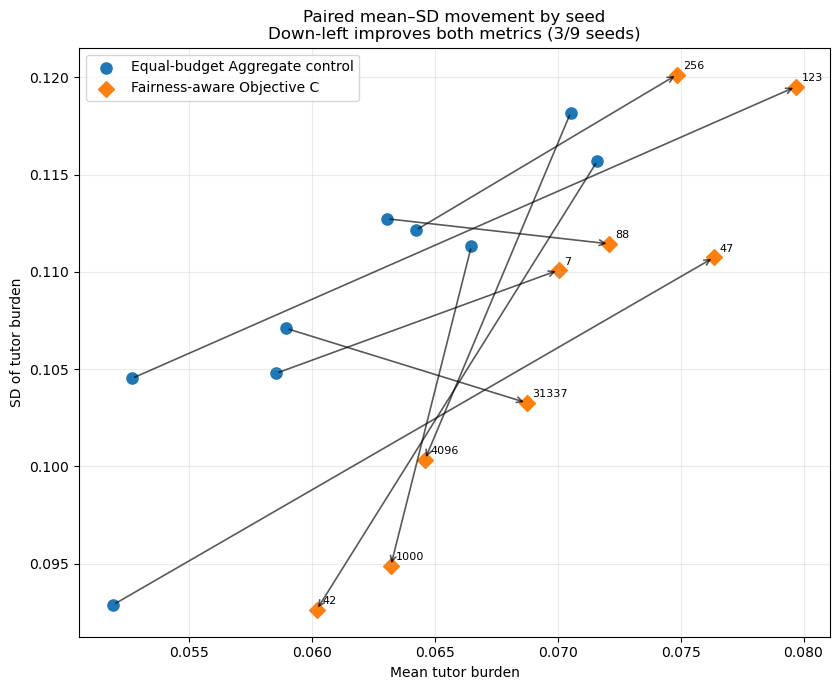

In [20]:
# --Husain Naser update: paired mean–SD movement chart
# Each arrow starts at the equal-budget Aggregate control and ends at the
# fairness-aware result for the same seed. Movement down-left improves both metrics.
fig, ax = plt.subplots(figsize=(8.5, 7))

ax.scatter(
    robustness_df["aggregate_control_mean"],
    robustness_df["aggregate_control_sd"],
    marker="o",
    s=65,
    label="Equal-budget Aggregate control",
)
ax.scatter(
    robustness_df["fair_mean"],
    robustness_df["fair_sd"],
    marker="D",
    s=65,
    label="Fairness-aware Objective C",
)

for _, row in robustness_df.iterrows():
    ax.annotate(
        "",
        xy=(row["fair_mean"], row["fair_sd"]),
        xytext=(row["aggregate_control_mean"], row["aggregate_control_sd"]),
        arrowprops={"arrowstyle": "->", "alpha": 0.65, "linewidth": 1.2},
    )
    ax.annotate(
        str(int(row["seed"])),
        xy=(row["fair_mean"], row["fair_sd"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

both_improved = int(
    (
        (robustness_df["fair_mean"] < robustness_df["aggregate_control_mean"])
        & (robustness_df["fair_sd"] < robustness_df["aggregate_control_sd"])
    ).sum()
)

ax.set_xlabel("Mean tutor burden")
ax.set_ylabel("SD of tutor burden")
ax.set_title(
    "Paired mean–SD movement by seed\n"
    f"Down-left improves both metrics ({both_improved}/{len(robustness_df)} seeds)"
)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("fairness_mean_sd_dominance_v5.png", dpi=300, bbox_inches="tight")
plt.show()
# ---end of mod: husain naser---


## 10. Final schedule and highest-burden tutors

In [21]:
# --Husain Naser update: keep the existing conservative export gate only to choose
# one illustrative schedule. This strict dominance filter is NOT the study success criterion.
successful = robustness_df[robustness_df["all_metrics_dominance"]].copy()
if successful.empty:
    raise RuntimeError("No tested seed achieved all-metrics dominance; no schedule exported.")

selected_seed = int(
    successful.sort_values(
        # --Husain Naser update: select using the corrected Objective C and its
        # protected burden metrics; Gini remains reporting-only.
        ["fair_C_score", "fair_mean", "fair_sd", "fair_top10", "fair_max"],
        ascending=[True, True, True, True, True],
        # ---end of mod: husain naser---
    ).iloc[0]["seed"]
)
final_sessions = fairness_candidates[selected_seed]
assert count_hard_violations(final_sessions) == 0
assert count_logical_violations(final_sessions) == 0
print(f"Selected fairness-aware seed: {selected_seed}")
# ---end of mod: husain naser---

final_schedule_rows = []
for s in sorted(final_sessions, key=lambda s: (s["tutor"], DAY_ORDER.index(s["day"]), s["start"])):
    real_end = s["start"] + s["duration"]
    final_schedule_rows.append({
        "TUTOR_ID": s["tutor"], "COURSE_ID": s["course"], "CLASS_ID": s["class_id"],
        "SECTION": s["section"], "DAY": s["day"],
        "START": f"{s['start']//60:02d}:{s['start']%60:02d}",
        "END_ACTUAL": f"{real_end//60:02d}:{real_end%60:02d}",
        "END_SCHEDULED_BLOCK": f"{session_end(s)//60:02d}:{session_end(s)%60:02d}",
        "ROOM_ID": s["room"], "ROOM_TYPE": room_type_by_id.get(s["room"]), "CAMPUS_ID": s["campus"],
        "MERGED_GROUP_ID": s["merged_group"] or "",
    })

final_schedule_df = pd.DataFrame(final_schedule_rows)
final_schedule_df.to_csv(f"final_schedule_{SEMESTER}_v5.csv", index=False)
print(f"Final schedule written ({len(final_schedule_df)} rows)")
final_schedule_df.head(15)


Selected fairness-aware seed: 42
Final schedule written (556 rows)


,TUTOR_ID,COURSE_ID,CLASS_ID,SECTION,DAY,START,END_ACTUAL,END_SCHEDULED_BLOCK,ROOM_ID,ROOM_TYPE,CAMPUS_ID,MERGED_GROUP_ID
0,T001,IT7003,21271,015,Sunday,14:00,15:50,16:00,25.323,Lab,B,
1,T001,IT7003,21263,013,Sunday,18:00,19:50,20:00,25.115,Lab,B,
2,T001,IT7003,21269,014,Monday,10:00,11:50,12:00,19.120,General,A,MERGE157
3,T001,IT7003,21271,015,Monday,10:00,11:50,12:00,19.120,General,A,MERGE157
4,T001,IT7003,21263,013,Monday,14:00,15:50,16:00,25.328,Lab,B,
5,T001,IT7003,21269,014,Tuesday,14:00,15:50,16:00,25.324,Lab,B,
6,T001,IT7003,21271,015,Wednesday,12:00,13:50,14:00,25.327,Lab,B,
7,T001,IT7003,21269,014,Thursday,12:00,13:50,14:00,20.121,Lab,B,
8,T002,IT7008,21205,001,Sunday,12:00,13:50,14:00,20.263,Lab,B,
9,T002,IT7008,21210,002,Sunday,18:00,19:50,20:00,36.203,Lab,A,


In [22]:
# --Husain Naser update: compare the selected result with both the current timetable
# and the Aggregate timetable from which fairness refinement started.
final_V, _ = per_tutor_violations(final_sessions)
current_V, _ = per_tutor_violations(sessions)
aggregate_V = aggregate_V_by_seed[selected_seed]
highest_burden = sorted(final_V, key=lambda t: final_V[t], reverse=True)[:10]

print(
    f"{'TUTOR':8s} {'V current':>10s} {'V aggregate':>12s} "
    f"{'V final':>10s} {'change vs agg':>14s} {'active profiles (weight)':>40s}"
)
for t in highest_burden:
    current = current_V.get(t, 0.0)
    aggregate = aggregate_V.get(t, 0.0)
    after = final_V.get(t, 0.0)
    weights = tutor_weights.get(t, {})
    active = ", ".join(f"{p}={w:.2f}" for p, w in weights.items() if w > 0) or "none (P8)"
    print(
        f"{t:8s} {current:10.3f} {aggregate:12.3f} {after:10.3f} "
        f"{after - aggregate:14.3f} {active:>40s}"
    )
# ---end of mod: husain naser---


TUTOR     V current  V aggregate    V final  change vs agg                 active profiles (weight)
T057          0.389        0.639      0.333         -0.306                P1=0.50, P3=0.17, P6=0.33
T014          0.667        0.722      0.333         -0.389                         P3=0.67, P7=0.33
T077          0.611        0.704      0.315         -0.389                P2=0.33, P3=0.50, P7=0.17
T043          0.292        0.575      0.250         -0.325                P1=0.33, P3=0.17, P7=0.50
T110          0.354        0.417      0.250         -0.167                P1=0.50, P3=0.17, P7=0.33
T115          0.500        0.625      0.250         -0.375                                  P1=1.00
T021          0.500        0.250      0.250          0.000                                  P1=1.00
T080          0.444        0.611      0.222         -0.389                         P4=0.67, P6=0.33
T051          0.190        0.143      0.190          0.048                         P1=0.33, P4=0.67


## 11. Final study status

- Stage 1 optimizes hard/logical feasibility only; neither Stage-2 comparison objective
  influences the shared starting timetable.
- The final primary comparison remains **Aggregate mean-only control vs the original
  Objective C (0.40 mean + 0.35 SD + 0.25 worst-10%)** at the same 20,000-iteration budget.
- The separately pre-registered equity-only endpoint is retained as a negative robustness
  result; it does not replace Objective C.
- Burden Gini is diagnostic only because of the zero-burden/mean confounding found in the
  final audit. Satisfaction Gini is the final reporting-only metric-validity check.
- The Stage-2 curves are treated as a fixed-budget comparison, **not proof of convergence**.
- The lambda sweep is retired and disabled. No further objective or hyperparameter tuning is
  performed after this final run.

<!-- Husain Naser update: final frozen methodology/status summary. -->


## 12. Individual tutor checker — built in

Shows a specific tutor's profile, and for every profile with nonzero weight, the exact
raw count, ceiling, normalized value, and weighted contribution, before vs. after SA.
Replaces the ad-hoc version from before with one that matches the new normalized model.

In [23]:
TUTOR_ID = "T057"  # Husain Naser: showcase a tutor whose burden visibly improves
# --Husain Naser update: compare with the validated selected schedule.
COMPARE_AFTER = final_sessions
# ---end of mod: husain naser---

def explain_violations(label, sessions_state):
    # --Husain Naser update: a merged group is one tutor teaching event.
    tutor_sessions = [s for s in teaching_events(sessions_state) if s["tutor"] == TUTOR_ID]
    # ---end of mod: husain naser---
    by_day = defaultdict(list)
    campus_by_day = defaultdict(list)
    for s in tutor_sessions:
        by_day[s["day"]].append(s)
        campus_by_day[s["day"]].append(s["campus"])

    print(f"--- {label} ---")
    weights = tutor_weights.get(TUTOR_ID, {p: (1.0 if p == "P8" else 0.0) for p in PROFILE_COLS})
    active = [(p, w) for p, w in weights.items() if w > 0]
    active.sort(key=lambda pw: -pw[1])  # highest weight first

    if not active or active[0][0] == "P8":
        print("Profile: P8, no preference. V(t) = 0 by construction.\n")
        return

    N = len(tutor_sessions)
    min_days_t = MIN_DAYS_MAP.get(TUTOR_ID, 1)

    # v5 tutors hold weighted vectors, not one profile, so this loops through every
    # active one. Each branch prints the exact sessions/pairs/days triggering the
    # violation, then the raw/ceiling/normalized/weighted numbers that feed V(t) --
    # matching Section 4's table and the current (post-Aug-5) profile definitions,
    # not the pre-threshold, pre-120-min-boundary logic from earlier notebooks.
    for profile, weight in active:
        print(f"Profile {profile} (weight {weight:.2f}):")

        if profile == "P1":  # morning-only
            bad = [s for s in tutor_sessions if not is_morning(s["start"])]
            print("  Rule: morning-only. Sessions at/after 12:00 (each a violation):")
            for s in bad:
                print(f"    {s['course']} sec {s['section']}, {s['day']} "
                      f"{s['start']//60:02d}:{s['start']%60:02d}")
            raw, ceiling = len(bad), N

        elif profile == "P2":  # night owl
            bad = [s for s in tutor_sessions if is_morning(s["start"])]
            print("  Rule: night owl. Sessions before 12:00 (each a violation):")
            for s in bad:
                print(f"    {s['course']} sec {s['section']}, {s['day']} "
                      f"{s['start']//60:02d}:{s['start']%60:02d}")
            raw, ceiling = len(bad), N

        elif profile == "P3":  # compact week -- first 3 days are free
            days_used = len(by_day)
            raw = max(0, days_used - 3)
            ceiling = max(0, min(N, TOTAL_DAYS_AVAILABLE) - 3)
            print(f"  Rule: compact week, first 3 days free. Days used: {sorted(by_day.keys())} ({days_used} total)")
            print(f"  -> {raw} violation(s) (only the 4th/5th day counts)")

        elif profile == "P4":  # prefers full week -- no threshold, no forgiveness
            days_used = len(by_day)
            raw = max(TOTAL_DAYS_AVAILABLE - days_used, 0)
            ceiling = TOTAL_DAYS_AVAILABLE - min_days_t
            print(f"  Rule: prefers full week, no threshold. Days used: {sorted(by_day.keys())} ({days_used}/5)")

        elif profile == "P5":  # prefers idle time -- violation if gap < 1 full slot (120 min)
            raw = 0
            print("  Rule: prefers idle time. Gaps UNDER 120 min, including back-to-back (each a violation):")
            for day, items in by_day.items():
                its = sorted(items, key=lambda s: s["start"])
                for i in range(len(its) - 1):
                    gap = its[i+1]["start"] - session_end(its[i])
                    if gap < SLOT_MINUTES:
                        raw += 1
                        print(f"    {day}: {gap} min gap between {its[i]['course']} sec {its[i]['section']} "
                              f"and {its[i+1]['course']} sec {its[i+1]['section']}")
            ceiling = max(N - min_days_t, 0)

        elif profile == "P6":  # dislikes idle time -- violation if gap >= 1 full slot (120 min)
            raw = 0
            print("  Rule: dislikes idle time. Gaps of 120 min or more (each a violation):")
            for day, items in by_day.items():
                its = sorted(items, key=lambda s: s["start"])
                for i in range(len(its) - 1):
                    gap = its[i+1]["start"] - session_end(its[i])
                    if gap >= SLOT_MINUTES:
                        raw += 1
                        print(f"    {day}: {gap} min gap between {its[i]['course']} sec {its[i]['section']} "
                              f"and {its[i+1]['course']} sec {its[i+1]['section']}")
            ceiling = max(N - min_days_t, 0)

        elif profile == "P7":  # campus-consistency
            raw = 0
            print("  Rule: campus-consistency. Days with more than one campus, each extra campus a violation:")
            for day, campuses in campus_by_day.items():
                distinct = sorted(set(campuses))
                if len(distinct) > 1:
                    raw += len(distinct) - 1
                    print(f"    {day}: campuses visited {distinct}")
            ceiling = max(N - min_days_t, 0)

        normalized = min((raw / ceiling) if ceiling > 0 else 0.0, 1.0)
        print(f"  -> raw={raw}, ceiling={ceiling}, normalized={normalized:.3f}, "
              f"weighted contribution={weight * normalized:.3f}")
        print()

    V, _ = per_tutor_violations(sessions_state)
    print(f"V({TUTOR_ID}) = {V.get(TUTOR_ID, 0):.3f}\n")

explain_violations("BEFORE (baseline)", sessions)
explain_violations("AFTER (selected fairness-aware schedule)", COMPARE_AFTER)


--- BEFORE (baseline) ---
Profile P1 (weight 0.50):
  Rule: morning-only. Sessions at/after 12:00 (each a violation):
    IT7005 sec 002, Monday 12:00
    IT7005 sec 003, Wednesday 12:00
    IT7008 sec 003, Thursday 14:00
    IT7008 sec 003, Sunday 12:00
  -> raw=4, ceiling=9, normalized=0.444, weighted contribution=0.222

Profile P6 (weight 0.33):
  Rule: dislikes idle time. Gaps of 120 min or more (each a violation):
  -> raw=0, ceiling=6, normalized=0.000, weighted contribution=0.000

Profile P3 (weight 0.17):
  Rule: compact week, first 3 days free. Days used: ['Monday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday'] (5 total)
  -> 2 violation(s) (only the 4th/5th day counts)
  -> raw=2, ceiling=2, normalized=1.000, weighted contribution=0.167

V(T057) = 0.389

--- AFTER (selected fairness-aware schedule) ---
Profile P1 (weight 0.50):
  Rule: morning-only. Sessions at/after 12:00 (each a violation):
    IT7005 sec 002, Monday 12:00
    IT7005 sec 003, Monday 14:00
  -> raw=2, ceilin